In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

Figure 15: Ablation study of flip augmentation and temporal bridging modules on 3DPW dataset.

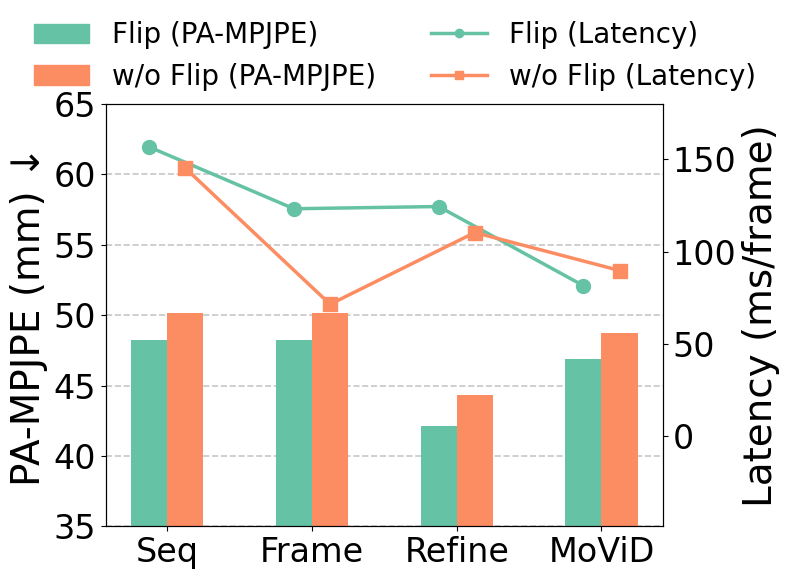

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
import os

# === Create folder ===
os.makedirs('./figures', exist_ok=True)

# === Data ===
methods = ['Seq', 'Frame', 'Refine', 'MoViD']
x = np.arange(len(methods))
width = 0.25

# flip / w/o flip data
pa_mpjpe_flip = np.array([48.26, 48.22, 42.10, 46.88])
pa_mpjpe_woflip = np.array([50.16, 50.14, 44.32, 48.70])
latency_flip = np.array([156.7, 123.2, 124.4, 81.5])
latency_woflip = np.array([145.2, 71.4, 110.3, 89.7])

# === Colors / Markers ===
colors = ['#66c2a5', '#fc8d62']  # flip / w/o flip
markers = ['o', 's']

# === Legend handles ===
legend_handles = [
    Rectangle((0, 0), 1, 1, color=colors[0], label='Flip (PA-MPJPE)'),
    Rectangle((0, 0), 1, 1, color=colors[1], label='w/o Flip (PA-MPJPE)'),
    Line2D([0], [0], color=colors[0], marker=markers[0], linewidth=2.5, label='Flip (Latency)'),
    Line2D([0], [0], color=colors[1], marker=markers[1], linewidth=2.5, label='w/o Flip (Latency)'),
]

# === Plot ===
fig, ax2 = plt.subplots(figsize=(8, 6))
ax1 = ax2.twinx()

# === Bars: PA-MPJPE ===
ax2.bar(x - width/2, pa_mpjpe_flip, width=width, color=colors[0], edgecolor='black', linewidth=0, zorder=2)
ax2.bar(x + width/2, pa_mpjpe_woflip, width=width, color=colors[1], edgecolor='black', linewidth=0, zorder=2)

# Annotate PA-MPJPE values
# for xi, (v1, v2) in zip(x, zip(pa_mpjpe_flip, pa_mpjpe_woflip)):
#     ax2.text(xi - width/2, v1 + 0.5, f'{v1:.1f}', ha='center', va='bottom', fontsize=14, fontweight='bold')
#     ax2.text(xi + width/2, v2 + 0.5, f'{v2:.1f}', ha='center', va='bottom', fontsize=14, fontweight='bold')

# === Lines: Latency ===
ax1.plot(x - width/2, latency_flip, color=colors[0], marker=markers[0], linewidth=2.5, markersize=10)
ax1.plot(x + width/2, latency_woflip, color=colors[1], marker=markers[1], linewidth=2.5, markersize=10)

# # Annotate Latency
# for xi, (v1, v2) in zip(x, zip(latency_flip, latency_woflip)):
#     ax1.text(xi - width/2, v1 + 3, f'{v1:.1f}', ha='center', va='bottom', fontsize=14, fontweight='bold')
#     ax1.text(xi + width/2, v2 + 3, f'{v2:.1f}', ha='center', va='bottom', fontsize=14, fontweight='bold')

# === Axes ===
ax2.set_ylabel('PA-MPJPE (mm) ↓', fontsize=28)
ax1.set_ylabel('Latency (ms/frame)', fontsize=28)
ax2.set_ylim(35, 65)
ax1.set_ylim(-49, 180)
ax2.set_xticks(x)
ax2.set_xticklabels(methods, fontsize=24)
ax1.tick_params(axis='y', labelsize=24)
ax2.tick_params(axis='y', labelsize=24)
ax2.grid(axis='y', linestyle='--', linewidth=1.2, alpha=0.7)
ax2.axhline(y=0, color='black', linewidth=1.2)
ax2.set_axisbelow(True)

# === Legend ===
fig.legend(handles=legend_handles, loc='upper center', ncol=2, fontsize=20, bbox_to_anchor=(0.5, 0.98), frameon=False)

# === Layout ===
plt.tight_layout()
plt.subplots_adjust(top=0.8)
plt.savefig('./figures/pa_mpjpe_latency_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


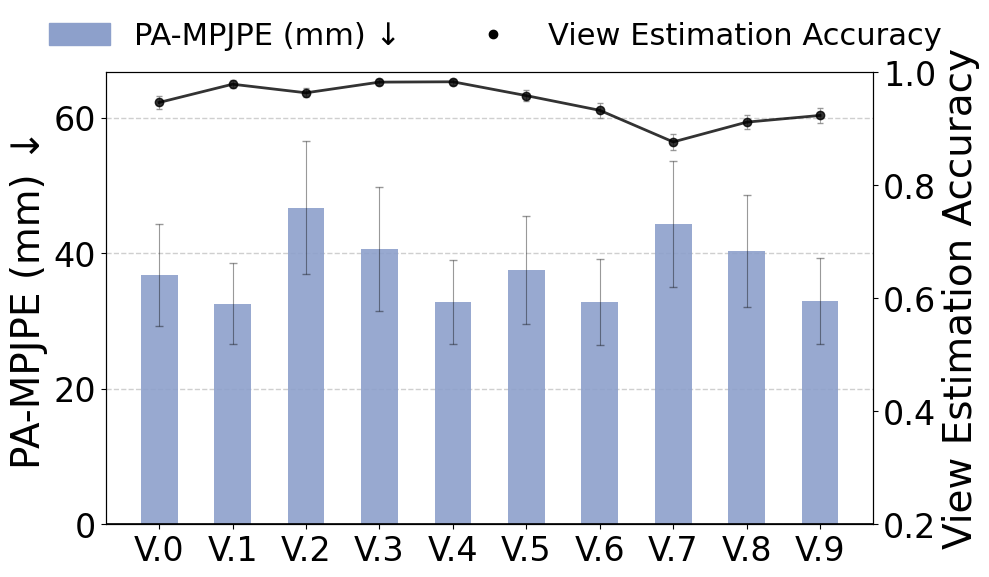

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
import os

# === 创建保存目录 ===
os.makedirs('./figures', exist_ok=True)

# === 数据 ===
views = [f"V.{i}" for i in range(10)]

PA_MPJPE = np.array([36.8300, 32.5335, 46.7236, 40.6789, 32.8412,
                     37.5483, 32.7814, 44.3175, 40.3040, 32.9663])
PA_MPJPE_STD = np.array([12.5561, 9.9494, 16.4511, 15.2512, 10.3372,
                         13.2684, 10.5351, 15.5350, 13.8632, 10.5297])

COS_SIM = np.array([0.9461, 0.9784, 0.9632, 0.9821, 0.9827,
                    0.9582, 0.9322, 0.8763, 0.9113, 0.9232])
COS_SIM_STD = np.array([0.0187, 0.0113, 0.0133, 0.0081, 0.0090,
                        0.0164, 0.0218, 0.0245, 0.0215, 0.0216])

x = np.arange(len(views))

# === 配色与样式 ===
color_bar = '#8da0cb'   # 柱状图：紫色
color_line = '#000000'  # 折线：黑色
marker_style = 'o'

# === 图例句柄 ===
legend_handles = [
    Rectangle((0, 0), 1, 1, color=color_bar, label='PA-MPJPE (mm) ↓'),
    Line2D([0], [0], color=color_line, marker=marker_style, linewidth=0, label='View Estimation Accuracy')
]

# === 绘图 ===
fig, ax2 = plt.subplots(figsize=(10, 6))
ax1 = ax2.twinx()

# --- Bar: PA-MPJPE ---
# --- Bar: PA-MPJPE ---
ax2.bar(
    x, PA_MPJPE, width=0.5, yerr=PA_MPJPE_STD * 0.6,  # 缩短误差线长度（60%）
    capsize=3, color=color_bar, edgecolor='black', linewidth=0,
    alpha=0.9, zorder=2,
    error_kw=dict(elinewidth=0.8, ecolor='black', alpha=0.4)
)

# --- Line: Cosine Similarity ---
ax1.errorbar(
    x, COS_SIM, yerr=COS_SIM_STD * 0.6,  # 缩短误差线长度（40%）
    fmt='-o', color=color_line, ecolor='gray',
    elinewidth=0.6, capsize=2, alpha=0.8,
    markersize=6, linewidth=2.0, zorder=3
)

# === 坐标轴设置 ===
ax2.set_ylabel("PA-MPJPE (mm) ↓", fontsize=28)
ax1.set_ylabel("View Estimation Accuracy", fontsize=28)
ax2.set_ylim(0, np.max(PA_MPJPE) + 20)
ax1.set_ylim(0.2, 1.00)
ax2.set_xticks(x)
ax2.set_xticklabels(views, fontsize=24)
ax2.tick_params(axis='y', labelsize=24)
ax1.tick_params(axis='y', labelsize=24)
ax2.grid(axis='y', linestyle='--', linewidth=1.0, alpha=0.6)
ax2.axhline(y=0, color='black', linewidth=1.2)
ax2.set_axisbelow(True)

# === 图例 ===
fig.legend(handles=legend_handles, loc='upper center', ncol=2,
           fontsize=22, frameon=False, bbox_to_anchor=(0.5, 0.98))

# === 布局 ===
plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.savefig('./figures/pa_mpjpe_cosine_similarity_pattern.png', dpi=300, bbox_inches='tight')
plt.show()


INFO:root:Saved plot to figures/error_propagation_combined_robust.png


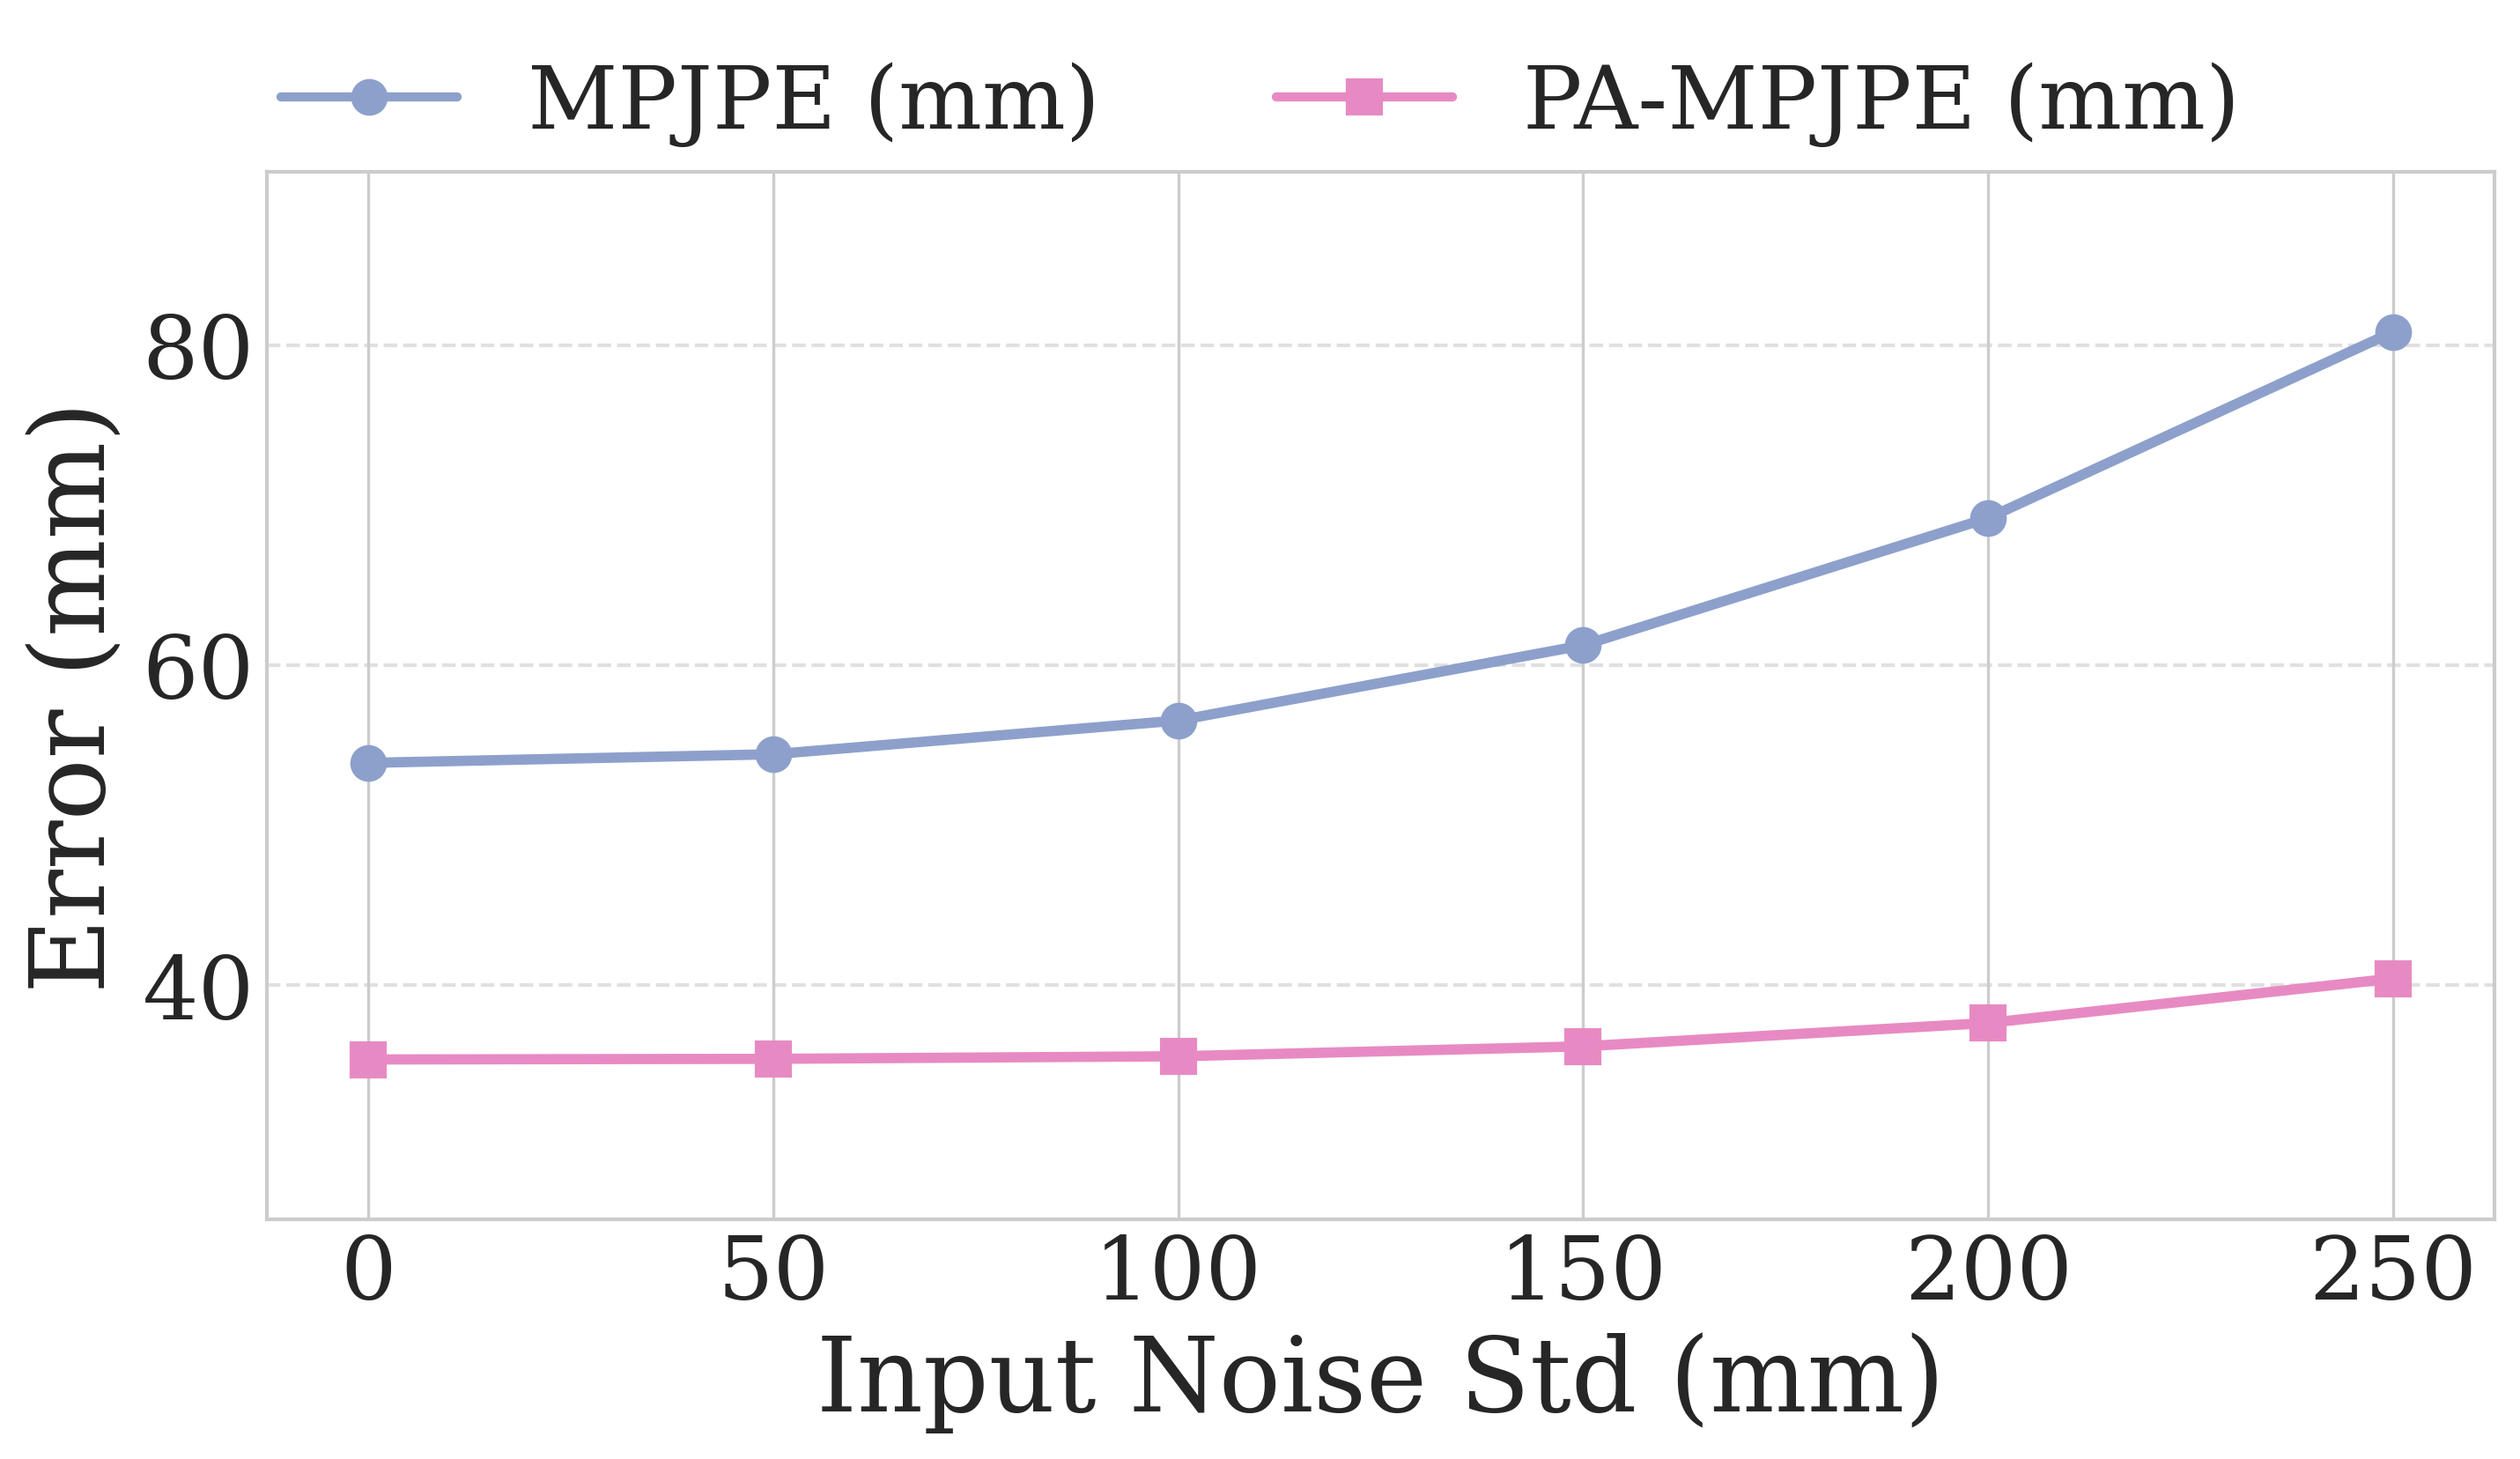

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import os
import logging
from matplotlib.lines import Line2D

# --- 日志记录器 ---
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger()

# === 样式参数 ===
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 22,
    'axes.titlesize': 26,
    'axes.labelsize': 24,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 20,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

# === 主函数 ===
def plot_results_combined(results_dict, output_dir, logger):
    """绘制 MPJPE 与 PA-MPJPE 曲线（论文风格）"""
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # ---- 数据 ----
    noise_mm = np.array([n * 1000 for n in results_dict.keys()])
    mpjpe_vals = np.array([v['mpjpe'] for v in results_dict.values()])
    pa_mpjpe_vals = np.array([v['pa_mpjpe'] for v in results_dict.values()])

    # ---- 颜色与标记（与 robustness 一致）----
    colors = ['#8da0cb', '#e78ac3']  # 紫色 + 黑色
    markers = ['o', 's']

    # ---- 图例句柄 ----
    legend_handles = [
        Line2D([0], [0], color=colors[0], marker=markers[0], linewidth=2.5,
               markersize=9, label='MPJPE (mm)'),
        Line2D([0], [0], color=colors[1], marker=markers[1], linewidth=2.5,
               markersize=9, label='PA-MPJPE (mm)')
    ]

    # ---- 绘图 ----
    fig, ax = plt.subplots(figsize=(10, 6))

    # MPJPE
    ax.plot(noise_mm, mpjpe_vals, marker=markers[0], color=colors[0],
            linewidth=2.8, markersize=9, label='MPJPE (mm)', zorder=3)

    # PA-MPJPE
    ax.plot(noise_mm, pa_mpjpe_vals, marker=markers[1], color=colors[1],
            linewidth=2.8, markersize=9, label='PA-MPJPE (mm)', zorder=3)

    # --- Y轴范围与样式 ---
    all_data = np.concatenate([mpjpe_vals, pa_mpjpe_vals])
    ax.set_ylim(all_data.min() - 10, all_data.max() + 10)

    # --- 坐标轴 ---
    ax.set_xlabel('Input Noise Std (mm)', fontsize=28)
    ax.set_ylabel('Error (mm)', fontsize=28)
    ax.set_xticks(noise_mm)
    ax.tick_params(axis='x', labelsize=24)
    ax.tick_params(axis='y', labelsize=24)
    ax.grid(axis='y', linestyle='--', linewidth=1.0, alpha=0.6)
    ax.set_axisbelow(True)

    # --- 图例 ---
    fig.legend(handles=legend_handles, loc='upper center', ncol=2,
               fontsize=24, frameon=False, bbox_to_anchor=(0.5, 0.97))

    # --- 布局与保存 ---
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    save_path = os.path.join(output_dir, "error_propagation_combined_robust.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    logger.info(f"Saved plot to {save_path}")
    plt.show()


# === 示例数据 ===
results_data = {
    0.0: {'mpjpe': 53.90, 'pa_mpjpe': 35.37, 'accel_err': 26.51},
    0.05: {'mpjpe': 54.44, 'pa_mpjpe': 35.41, 'accel_err': 29.95},
    0.10: {'mpjpe': 56.55, 'pa_mpjpe': 35.57, 'accel_err': 38.28},
    0.15: {'mpjpe': 61.25, 'pa_mpjpe': 36.19, 'accel_err': 50.78},
    0.20: {'mpjpe': 69.20, 'pa_mpjpe': 37.65, 'accel_err': 67.47},
    0.25: {'mpjpe': 80.83, 'pa_mpjpe': 40.43, 'accel_err': 87.82},
}

# === 输出目录 ===
output_directory = "figures/"

# === 绘图 ===
plot_results_combined(results_data, output_directory, logger)

Figure 12

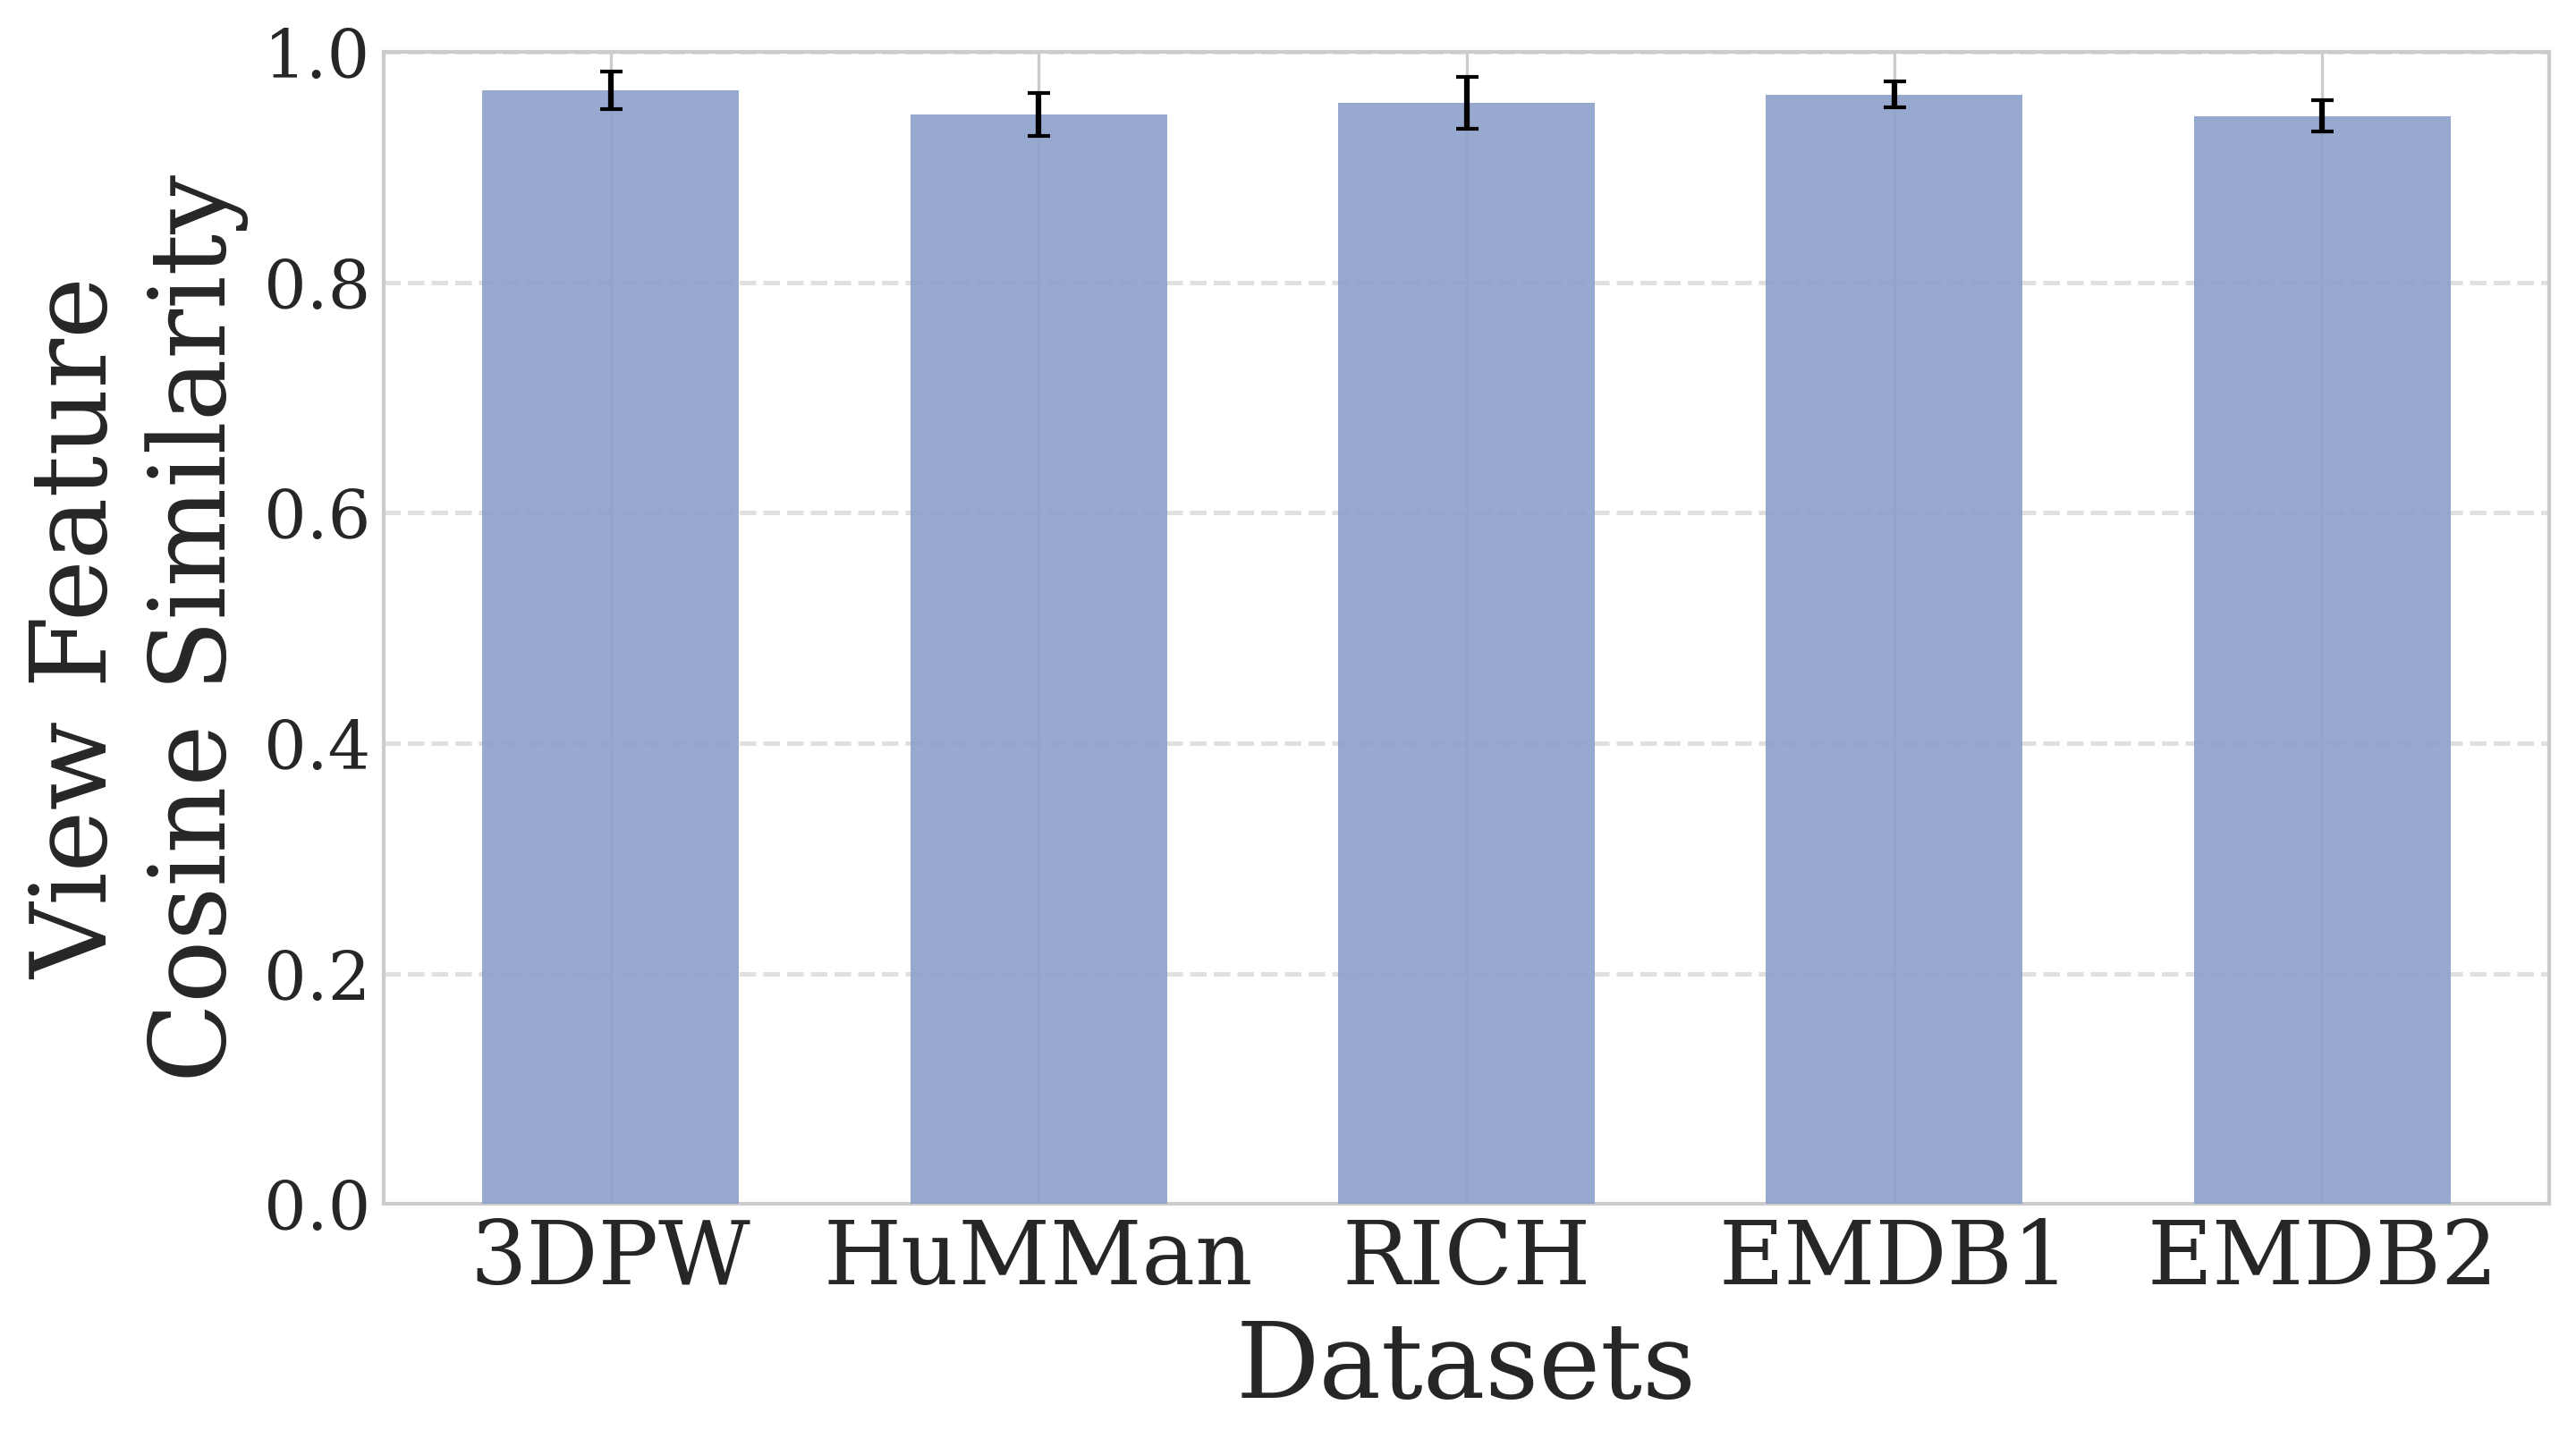

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# ==== 数据 ====
datasets = ["3DPW", "HuMMan", "RICH", "EMDB1", "EMDB2"]
cosine_similarity = [0.9668, 0.9454, 0.9557, 0.9628, 0.9443]
cosine_std = [0.0323, 0.0374, 0.0456, 0.0224, 0.0271]

# ==== 样式设置 ====
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 20,
    'axes.titlesize': 24,
    'axes.labelsize': 22,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 20,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

# === 颜色 ===
bar_color = '#8da0cb'     # 淡紫色，与 robustness 风格一致
edge_color = 'black'

# === 绘图 ===
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(datasets))
width = 0.6

# --- Bar: Cosine Similarity ---
bars = ax.bar(
    x,
    cosine_similarity,
    yerr=np.array(cosine_std) * 0.5,   # 缩短误差条长度（更精致）
    capsize=3,
    color=bar_color,
    edgecolor=edge_color,
    linewidth=0,
    alpha=0.9,
    zorder=3,
    width=width
)

# --- 数值标注 ---
# for bar in bars:
#     height = bar.get_height()
#     ax.text(
#         bar.get_x() + bar.get_width() / 2,
#         height + 0.01,
#         f'{height:.3f}',
#         ha='center',
#         va='bottom',
#         fontsize=16,
#         fontweight='bold'
#     )

# --- 坐标轴与标签 ---
ax.set_ylabel("View Feature\nCosine Similarity", fontsize=28)
ax.set_xlabel("Datasets", fontsize=28)
ax.set_xticks(x)
ax.set_xticklabels(datasets, fontsize=24)
ax.set_ylim(0, 1.00)
ax.grid(axis='y', linestyle='--', linewidth=1.2, alpha=0.6)
ax.axhline(y=0, color='black', linewidth=1.2)
ax.set_axisbelow(True)

# --- Legend (optional) ---
# legend_elements = [plt.Rectangle((0, 0), 1, 1, color=bar_color, label='Cosine Similarity')]
# fig.legend(handles=legend_elements, loc='upper center', fontsize=18, frameon=False, bbox_to_anchor=(0.5, 0.97))

# --- 布局与保存 ---
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.savefig('./new_figures/cosine_similarity_across_datasets.png', dpi=300, bbox_inches='tight')
plt.show()


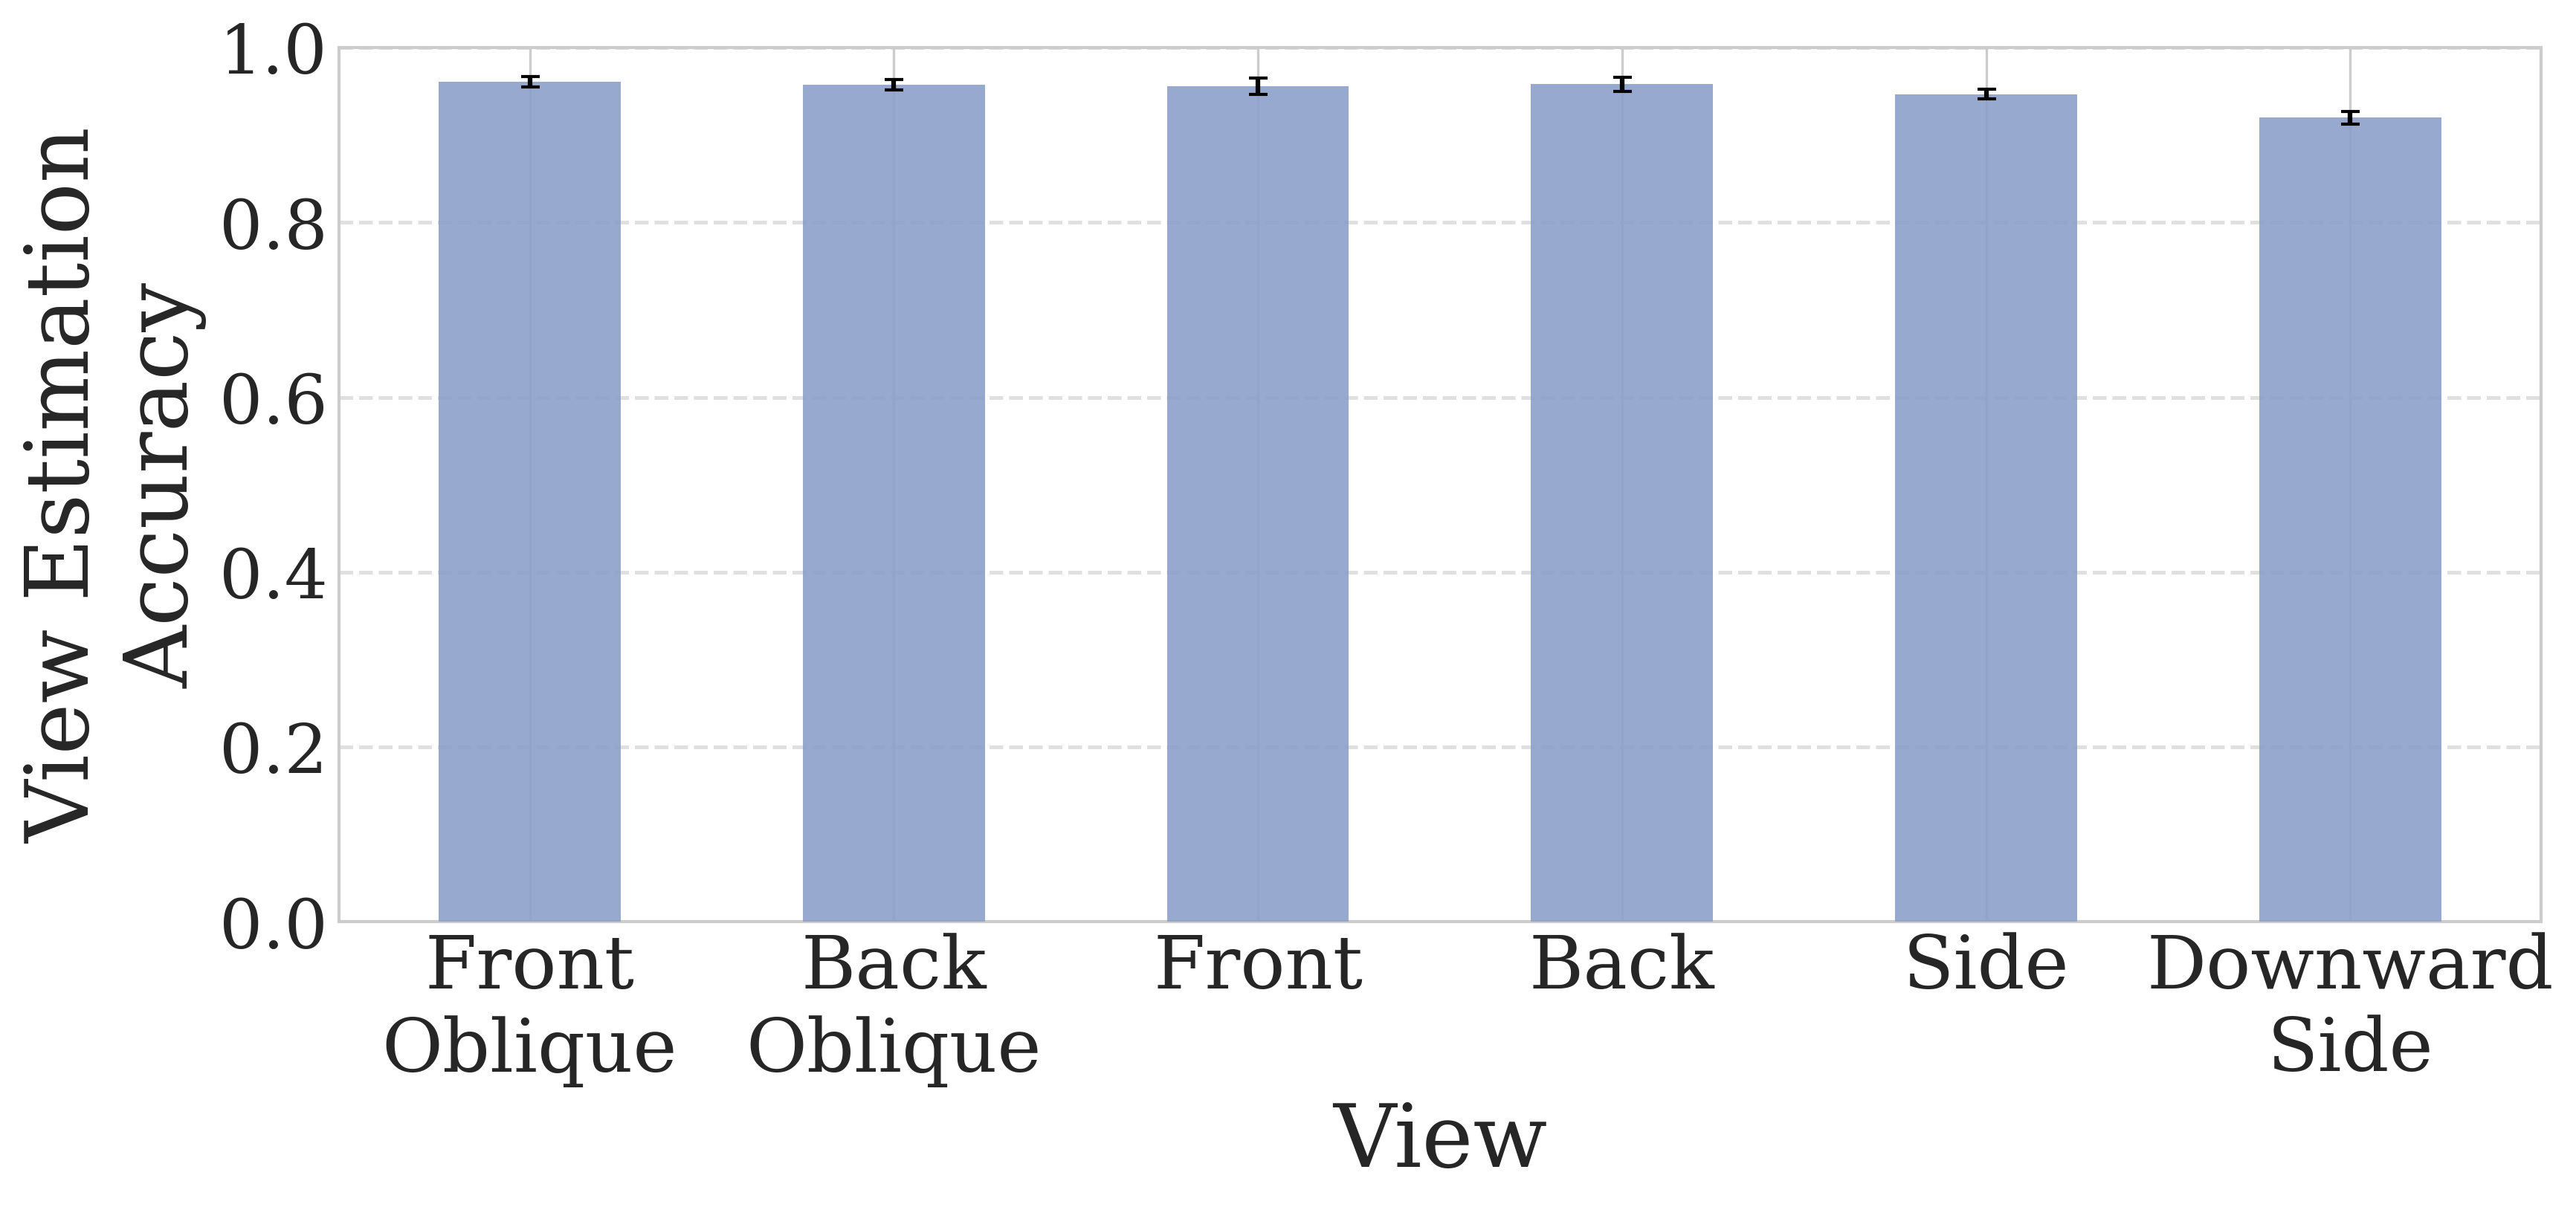

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import os

# ==== 创建保存目录 ====
os.makedirs('./new_figures', exist_ok=True)

# ==== 原始数据 ====
PA_MPJPE = np.array([36.8300, 32.5335, 46.7236, 40.6789, 32.8412,
                     37.5483, 32.7814, 44.3175, 40.3040, 32.9663])
PA_MPJPE_STD = np.array([12.5561, 9.9494, 16.4511, 15.2512, 10.3372,
                         13.2684, 10.5351, 15.5350, 13.8632, 10.5297])

COS_SIM = np.array([0.9561, 0.9784, 0.9632, 0.9821, 0.9827,
                    0.9582, 0.9322, 0.8763, 0.9113, 0.9432])
COS_SIM_STD = np.array([0.0187, 0.0113, 0.0133, 0.0081, 0.0090,
                        0.0164, 0.0218, 0.0245, 0.0215, 0.0216])

# ==== 合并视角 ====
views_merged = [
    'Front',
    'Front\nOblique',
    'Downward\nSide',
    'Side',
    'Back\nOblique',
    'Back'
]

PA_MPJPE_merged = np.array([
    PA_MPJPE[0],
    (PA_MPJPE[1] + PA_MPJPE[9]) / 2,
    (PA_MPJPE[2] + PA_MPJPE[7]) / 2,
    (PA_MPJPE[3] + PA_MPJPE[8]) / 2,
    (PA_MPJPE[4] + PA_MPJPE[6]) / 2,
    PA_MPJPE[5]
])

PA_MPJPE_STD_merged = np.array([
    PA_MPJPE_STD[0],
    np.sqrt(PA_MPJPE_STD[1]**2 + PA_MPJPE_STD[9]**2) / 2,
    np.sqrt(PA_MPJPE_STD[2]**2 + PA_MPJPE_STD[7]**2) / 2,
    np.sqrt(PA_MPJPE_STD[3]**2 + PA_MPJPE_STD[8]**2) / 2,
    np.sqrt(PA_MPJPE_STD[4]**2 + PA_MPJPE_STD[6]**2) / 2,
    PA_MPJPE_STD[5]
])

COS_SIM_merged = np.array([
    COS_SIM[0],
    (COS_SIM[1] + COS_SIM[9]) / 2,
    (COS_SIM[2] + COS_SIM[7]) / 2,
    (COS_SIM[3] + COS_SIM[8]) / 2,
    (COS_SIM[4] + COS_SIM[6]) / 2,
    COS_SIM[5]
])

COS_SIM_STD_merged = np.array([
    COS_SIM_STD[0],
    np.sqrt(COS_SIM_STD[1]**2 + COS_SIM_STD[9]**2) / 2,
    np.sqrt(COS_SIM_STD[2]**2 + COS_SIM_STD[7]**2) / 2,
    np.sqrt(COS_SIM_STD[3]**2 + COS_SIM_STD[8]**2) / 2,
    np.sqrt(COS_SIM_STD[4]**2 + COS_SIM_STD[6]**2) / 2,
    COS_SIM_STD[5]
])

# ==== 按 PA-MPJPE 升序排序 ====
sort_idx = np.argsort(PA_MPJPE_merged)

views_sorted = [views_merged[i] for i in sort_idx]
COS_sorted = COS_SIM_merged[sort_idx]
COS_std_sorted = COS_SIM_STD_merged[sort_idx]

# ==== 样式设置 ====
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 20,
    'axes.titlesize': 24,
    'axes.labelsize': 22,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 20,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})



# ==== 颜色 ====
bar_color = '#8da0cb'
edge_color = 'black'

# ==== 绘图 ====
fig, ax = plt.subplots(figsize=(12, 6))   # 原来是 (10, 6)
width = 0.5                               # 原来是 0.6

bars = ax.bar(
    x,
    COS_sorted,
    yerr=COS_std_sorted * 0.5,
    capsize=3,
    color=bar_color,
    edgecolor=edge_color,
    linewidth=0,
    alpha=0.9,
    zorder=3,
    width=width
)

# ==== 坐标轴与标签 ====
ax.set_ylabel("View Estimation\nAccuracy", fontsize=28)
ax.set_xlabel("View", fontsize=28)

ax.set_xticks(x)
ax.set_xticklabels(views_sorted, fontsize=24)

# 为了突出 good performance，建议不要从 0 开始
ax.set_ylim(0.00, 1.00)

ax.tick_params(axis='y', labelsize=22)
ax.grid(axis='y', linestyle='--', linewidth=1.2, alpha=0.6)
#ax.axhline(y=0.80, color='black', linewidth=1.2)
ax.set_axisbelow(True)

# ==== 布局与保存 ====
plt.tight_layout()
plt.subplots_adjust(top=0.9)

plt.savefig(
    './new_figures/view_estimation_accuracy_across_views_bar.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Figure 12: Cross-View Evaluation on PA\_MPJPE.

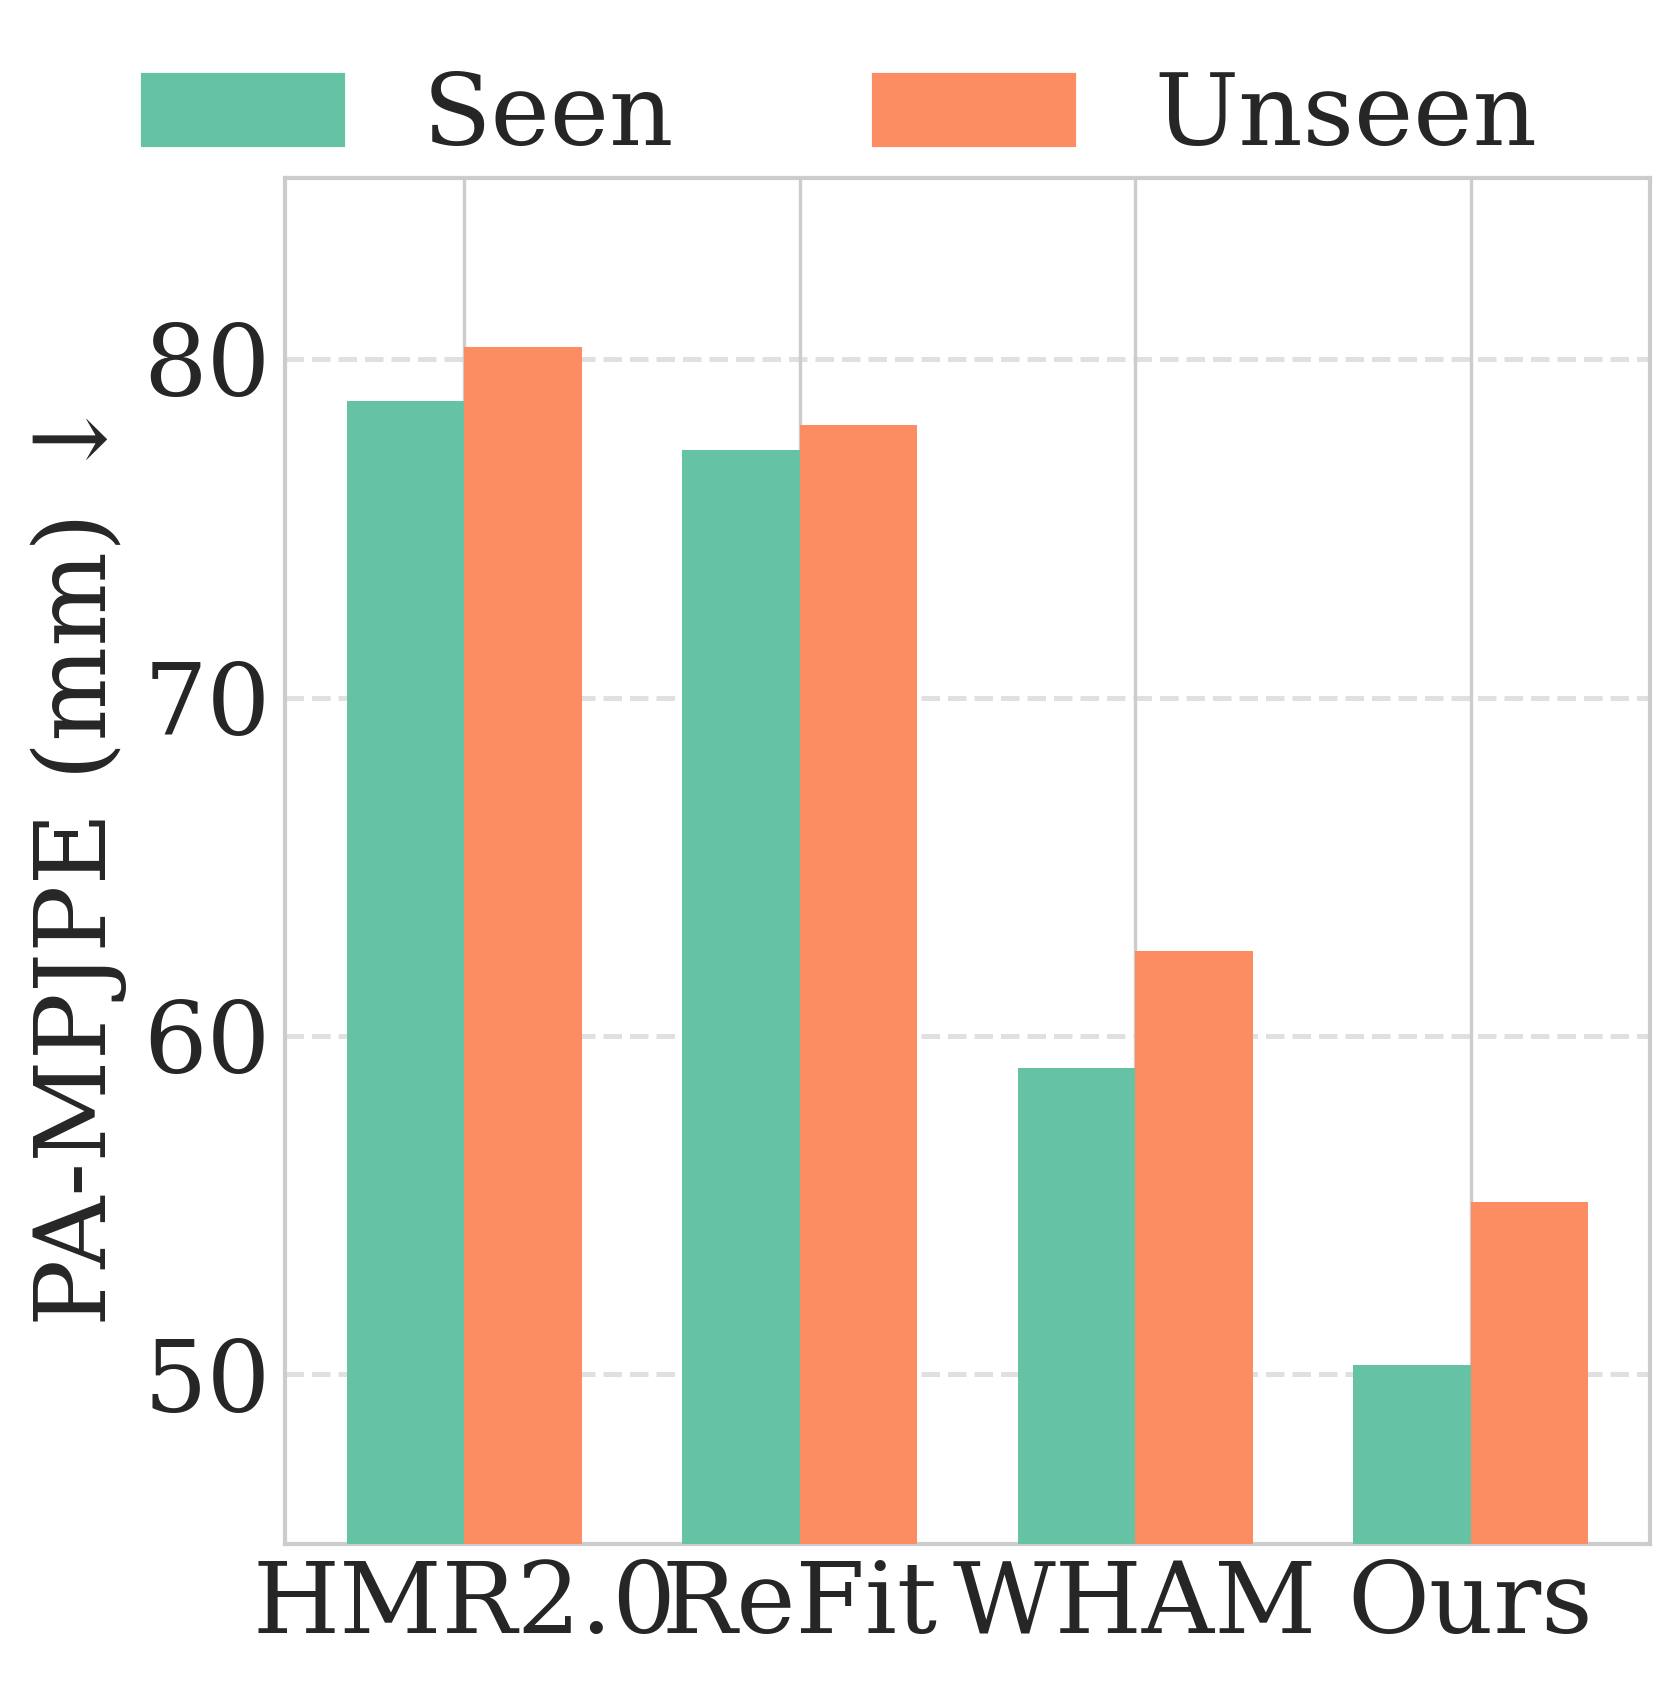

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.patches import Rectangle

# === 创建输出目录 ===
os.makedirs('./new_figure', exist_ok=True)

# === 数据 ===
methods = ['HMR2.0', 'ReFit', 'WHAM', 'Ours']

wham_data = [68.1324, 62.9202, 65.9226, 59.0274, 55.4554, 55.9412, 56.3560, 66.0706, 59.9957, 61.5070]
refit_data = [75.0, 77.5, 79.0, 76.3, 78.0, 80.2, 81.3, 83.0, 74.8, 72.4]
hmr2_data = [78.5, 76.2, 82.4, 79.3, 77.1, 80.0, 87.2, 86.3, 75.6, 74.6]
ours_data = [56.3067, 52.2722, 59.5482, 52.1459, 48.339, 49.8201, 48.6137, 59.6629, 53.0574, 51.8696]
seen_idx = [1, 4, 6, 9]
unseen_idx = [i for i in range(10) if i not in seen_idx]

# === 平均计算 ===
def calc_mean(values, idx):
    return np.mean([values[i] for i in idx])

seen_means = [calc_mean(hmr2_data, seen_idx),
              calc_mean(refit_data, seen_idx),
              calc_mean(wham_data, seen_idx),
              calc_mean(ours_data, seen_idx)]
unseen_means = [calc_mean(hmr2_data, unseen_idx),
                calc_mean(refit_data, unseen_idx),
                calc_mean(wham_data, unseen_idx),
                calc_mean(ours_data, unseen_idx)]

# === 样式 ===
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 20,
    'axes.titlesize': 28,
    'axes.labelsize': 24,
    'xtick.labelsize': 24,
    'ytick.labelsize': 24,
    'legend.fontsize': 24,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

colors = ['#66c2a5', '#fc8d62']   # 紫、粉
width = 0.35

# === 绘图 ===
fig, ax = plt.subplots(figsize=(6, 6))
x = np.arange(len(methods))

bars1 = ax.bar(x - width/2, seen_means, width, color=colors[0],
               edgecolor='black', linewidth=0, label='Seen Views', zorder=3)
bars2 = ax.bar(x + width/2, unseen_means, width, color=colors[1],
               edgecolor='black', linewidth=0, label='Unseen Views', zorder=3)

# === 数值标注 ===
# def annotate_bars(bars):
#     for bar in bars:
#         h = bar.get_height()
#         ax.text(bar.get_x() + bar.get_width()/2, h + 0.8, f'{h:.1f}',
#                 ha='center', va='bottom', fontsize=16, fontweight='bold')
#
# annotate_bars(bars1)
# annotate_bars(bars2)

# === 坐标轴与标签 ===
ax.set_ylabel('PA-MPJPE (mm) ↓')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylim(45, max(max(seen_means), max(unseen_means)) + 5)
ax.grid(axis='y', linestyle='--', linewidth=1.2, alpha=0.6)
ax.axhline(y=0, color='black', linewidth=1.2)
ax.set_axisbelow(True)

# === Legend ===
legend_handles = [
    Rectangle((0, 0), 1, 1, color=colors[0], label='Seen'),
    Rectangle((0, 0), 1, 1, color=colors[1], label='Unseen')
]
fig.legend(handles=legend_handles, loc='upper center', ncol=2,
           fontsize=24, frameon=False, bbox_to_anchor=(0.5, 0.98))

# === 布局与保存 ===
plt.tight_layout()
plt.subplots_adjust(top=0.87)
plt.savefig('./new_figures/performance_comparison_seen_unseen_pattern.png', dpi=300, bbox_inches='tight')
plt.show()

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.patches import Patch

os.makedirs('./new_figures', exist_ok=True)

# === 样式 ===
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 20,
    'axes.labelsize': 28,
    'xtick.labelsize': 24,
    'ytick.labelsize': 24,
    'legend.fontsize': 24,
    'figure.dpi': 300,
})

colors = ['#66c2a5', '#8da0cb', '#e78ac3']
markers = ['o', 's', '^']
linestyles = ['-', '--', '-.']
width = 0.35

# === 数据 ===
views = np.arange(10)
view_labels = [f'{i}' for i in range(10)]

pa_mpjpe_before = np.array([48.58, 45.94, 55.31, 48.17, 43.81, 45.18, 44.33, 55.83, 49.34, 46.14])
mpjpe_before    = np.array([84.52, 73.28, 79.24, 73.50, 70.05, 71.59, 71.80, 78.23, 77.13, 72.23])

pa_mpjpe_after = np.array([50.01, 48.19, 57.49, 50.65, 45.88, 46.40, 45.27, 58.93, 51.23, 47.34])
mpjpe_after    = np.array([86.65, 77.75, 82.79, 74.98, 73.78, 73.81, 72.99, 83.20, 80.31, 75.35])

pa_mpjpe_opt = np.array([42.23, 38.24, 49.40, 42.80, 38.24, 39.64, 38.16, 49.75, 43.72, 38.80])
mpjpe_opt    = np.array([99.60, 71.94, 78.82, 76.08, 69.86, 70.08, 70.22, 78.52, 79.18, 75.07])


# =====================================================
#  draw single plot with top legend (inside figure)
# =====================================================
def plot_single_line(metric_before, metric_after, metric_opt,
                     ylabel, ylim, save_path):

    fig, ax = plt.subplots(figsize=(12, 4))

    # === 三条线 ===
    ax.plot(views, metric_before, linestyle=linestyles[0], marker=markers[0],
            color=colors[0], linewidth=3, markersize=9, label='Flip')
    ax.plot(views, metric_after, linestyle=linestyles[1], marker=markers[1],
            color=colors[1], linewidth=3, markersize=9, label='No-Flip')
    ax.plot(views, metric_opt, linestyle=linestyles[2], marker=markers[2],
            color=colors[2], linewidth=3, markersize=9, label='Hidden')

    # === 坐标轴 ===
    ax.set_ylabel(ylabel)
    ax.set_xticks(views)
    ax.set_xticklabels(view_labels)
    ax.set_ylim(*ylim)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.set_axisbelow(True)

    # === 完全放到图外上方 ===
    fig.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, 0.98),   # ⭐ 往上提得更远，完全不遮挡
        ncol=3,
        frameon=False,
        prop={'size': 24},
        columnspacing=1.5
    )

    # === 顶部留出空间（legend 不被裁剪）===
    plt.tight_layout(rect=[0, 0, 1, 0.88])   # ⭐ 下压主图，使 legend 有空间

    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close(fig)



# =====================================================
#   生成两张图
# =====================================================

plot_single_line(
    pa_mpjpe_before, pa_mpjpe_after, pa_mpjpe_opt,
    ylabel="PA-MPJPE (mm)",
    ylim=(35, 65),
    save_path="./new_figures/flip_comparison_pa_mpjpe_only.png"
)

plot_single_line(
    mpjpe_before, mpjpe_after, mpjpe_opt,
    ylabel="MPJPE (mm)",
    ylim=(60, 105),
    save_path="./new_figures/flip_comparison_mpjpe_only.png"
)

print("Done.")


Done.


Figure 11: Accuracy of downstream tasks on action recognition and fall detection for the NTU RGB+D and UP-Fall Detection datasets.

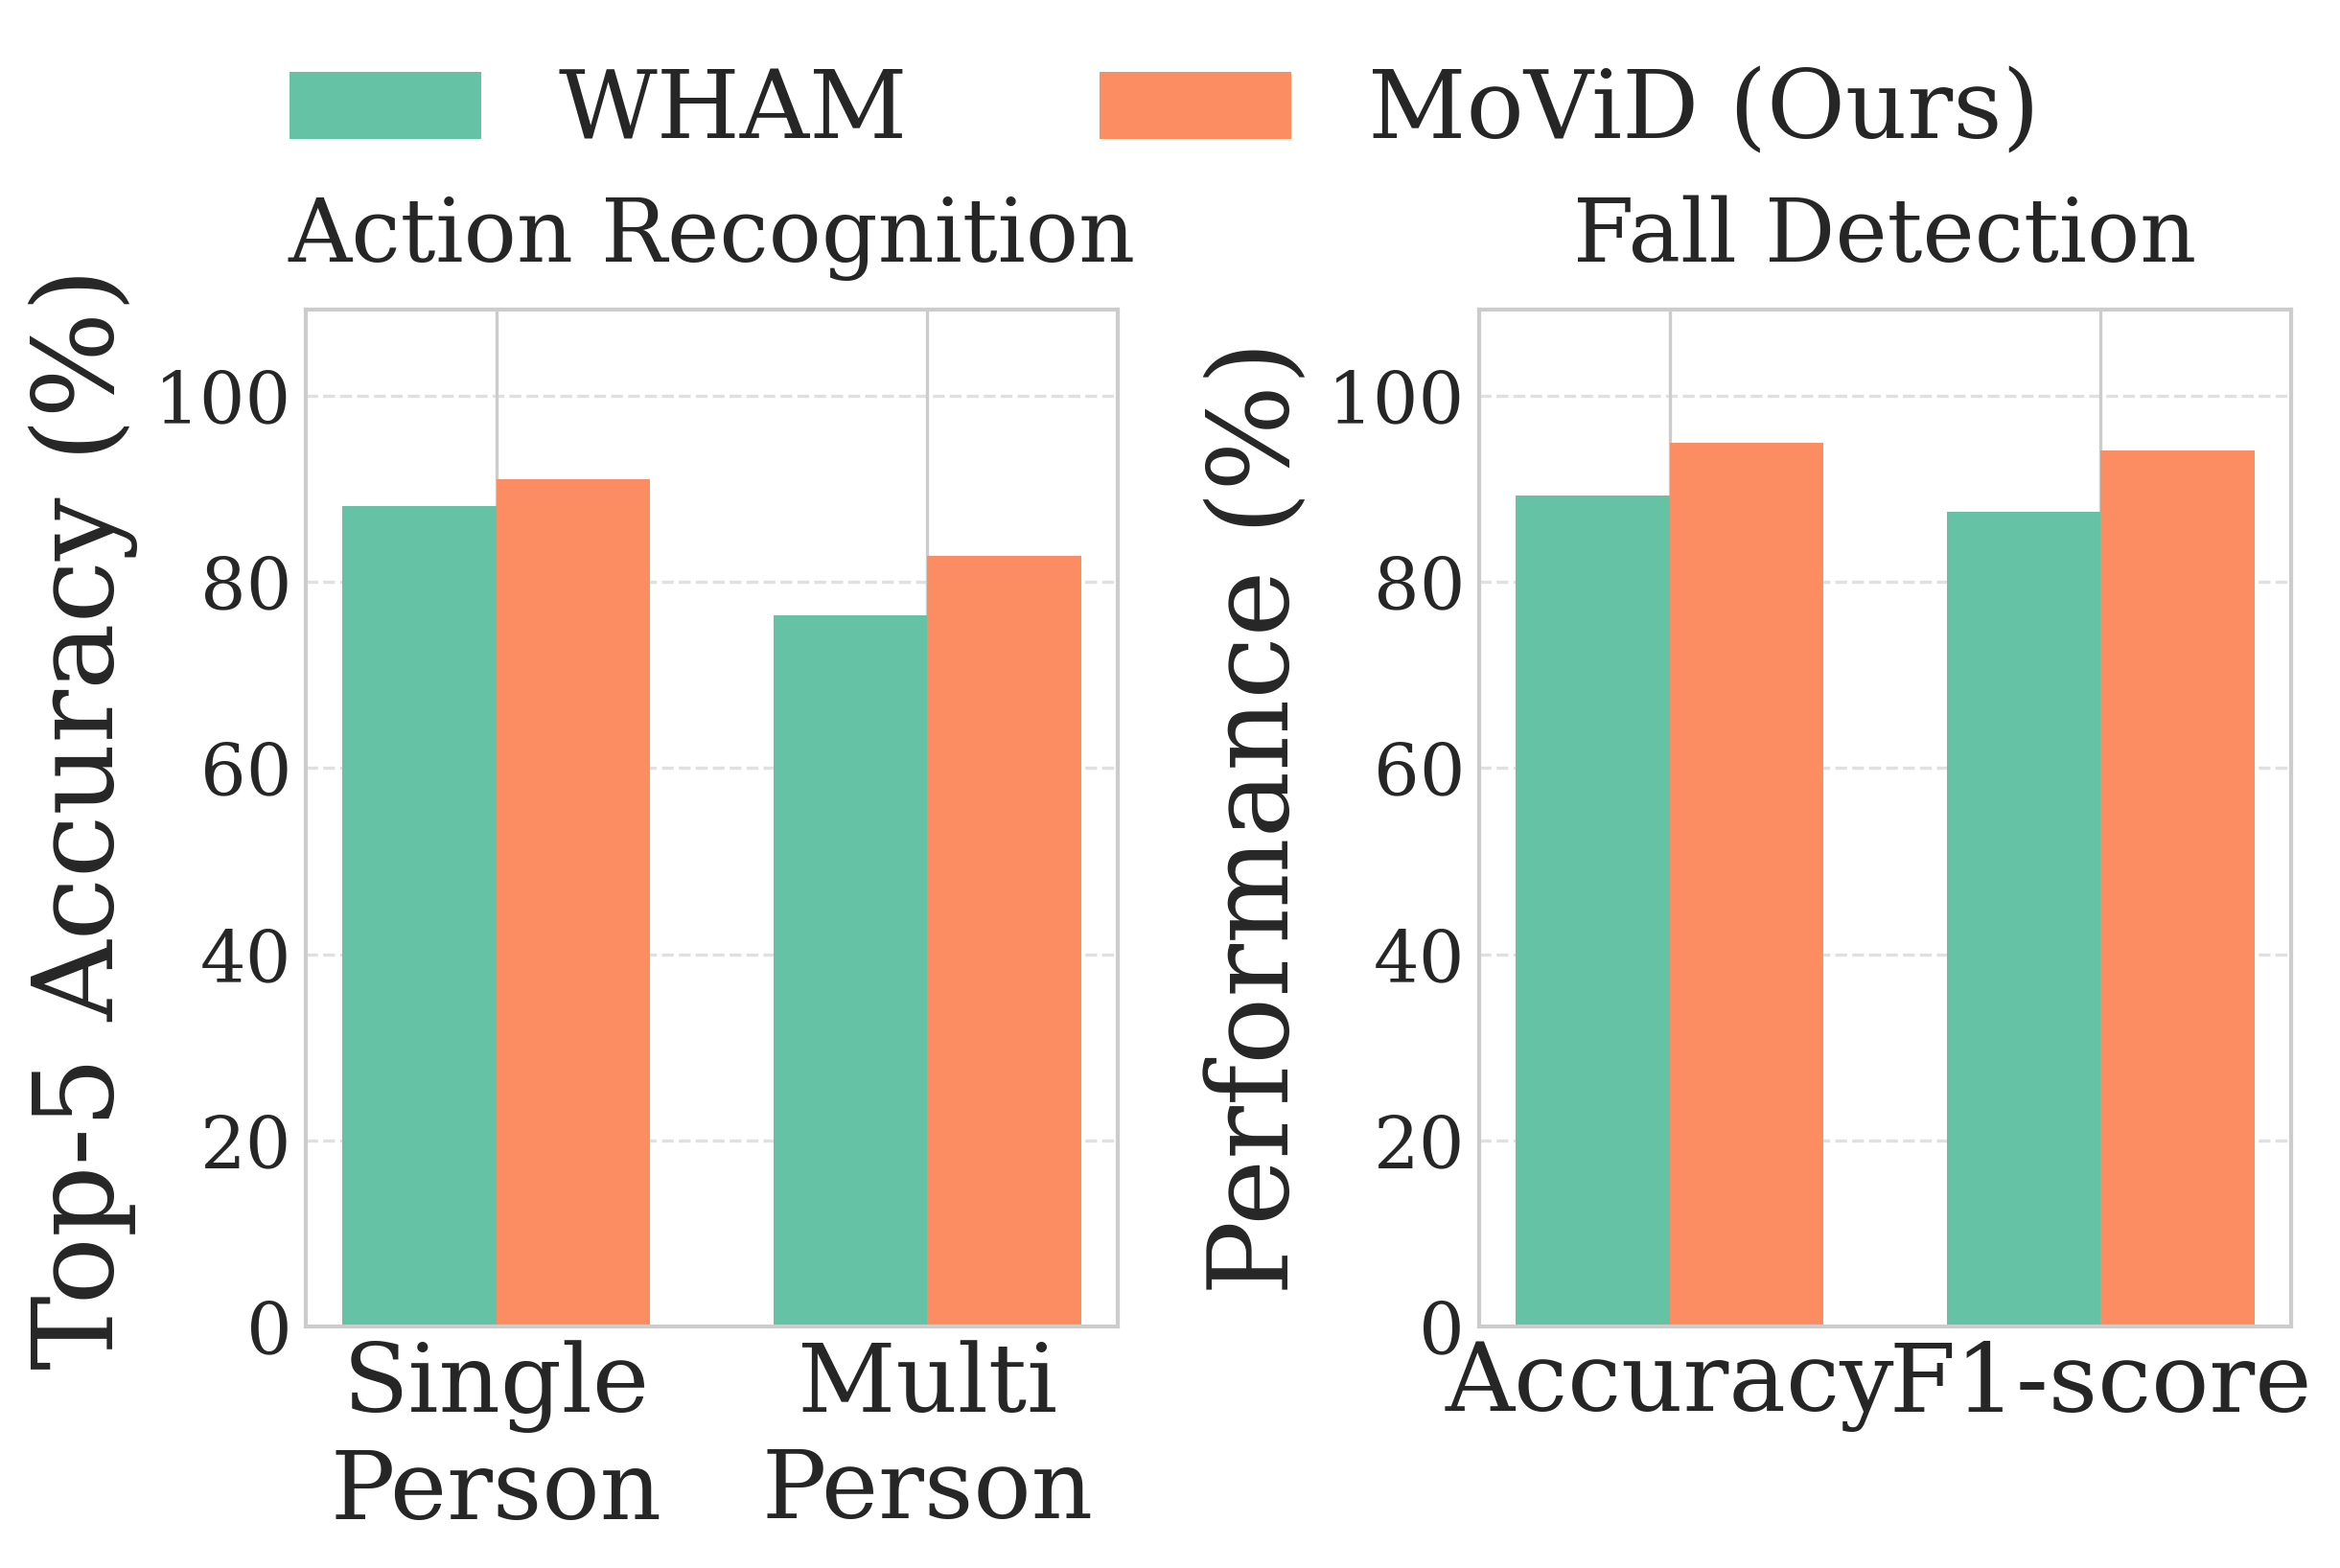

In [40]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
import os

# === 保存目录 ===
os.makedirs('./new_figures', exist_ok=True)

# === 全局风格 ===
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 22,
    'axes.titlesize': 22,
    'axes.labelsize': 20,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 22,
    'figure.dpi': 300,
})

# === 颜色 ===
COLORS = {
    'wham': '#66c2a5',
    'ours': '#fc8d62',
}

# ================================
#          数据
# ================================
action_rec_metrics = ['Single Person', 'Multi Person']
action_wham_scores = [88.2, 76.4]
action_ours_scores = [91.0, 82.8]

fall_det_metrics = ['Accuracy', 'F1-score']
fall_wham_scores = [89.3, 87.5]
fall_ours_scores = [95.0, 94.1]


# ================================
#   绘图函数（Legend 放最上面）
# ================================
def plot_single_task(xlabels, wham, ours, ylabel, filename):
    x = np.arange(len(xlabels))
    bar_width = 0.25

    fig, ax = plt.subplots(figsize=(6.5, 4.0))

    ax.bar(
        x - bar_width/2, wham, bar_width,
        color=COLORS['wham'], edgecolor='black', linewidth=0,
        label='WHAM'
    )
    ax.bar(
        x + bar_width/2, ours, bar_width,
        color=COLORS['ours'], edgecolor='black', linewidth=0,
        label='MoViD (Ours)'
    )

    ax.set_ylabel(ylabel, fontsize=24)
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, fontsize=22)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.set_axisbelow(True)

    # 统一 y 轴
    max_h = max(max(wham), max(ours))
    ax.set_ylim(0, max_h * 1.15)

    # === Legend 放在最上方一行，不遮挡图 ===
    fig.legend(
        loc='upper center',
        ncol=2,
        frameon=False,
        bbox_to_anchor=(0.5, 1.08),  # 图外上方
        fontsize=20
    )

    # 手动增加顶部空白
    plt.subplots_adjust(top=0.93)

    plt.savefig(f'./new_figures/{filename}.png', dpi=300, bbox_inches='tight')
    plt.close(fig)


# ================================
#   图 1
# ================================
plot_single_task(
    action_rec_metrics,
    action_wham_scores,
    action_ours_scores,
    ylabel='Top-5 Accuracy (%)',
    filename='movid_action_recognition'
)

# ================================
#   图 2
# ================================
plot_single_task(
    fall_det_metrics,
    fall_wham_scores,
    fall_ours_scores,
    ylabel='Performance (%)',
    filename='movid_fall_detection'
)

print("✅ Done! Two figures with top legends saved to ./new_figures/")


Figure 10: Performance with limited views during training.

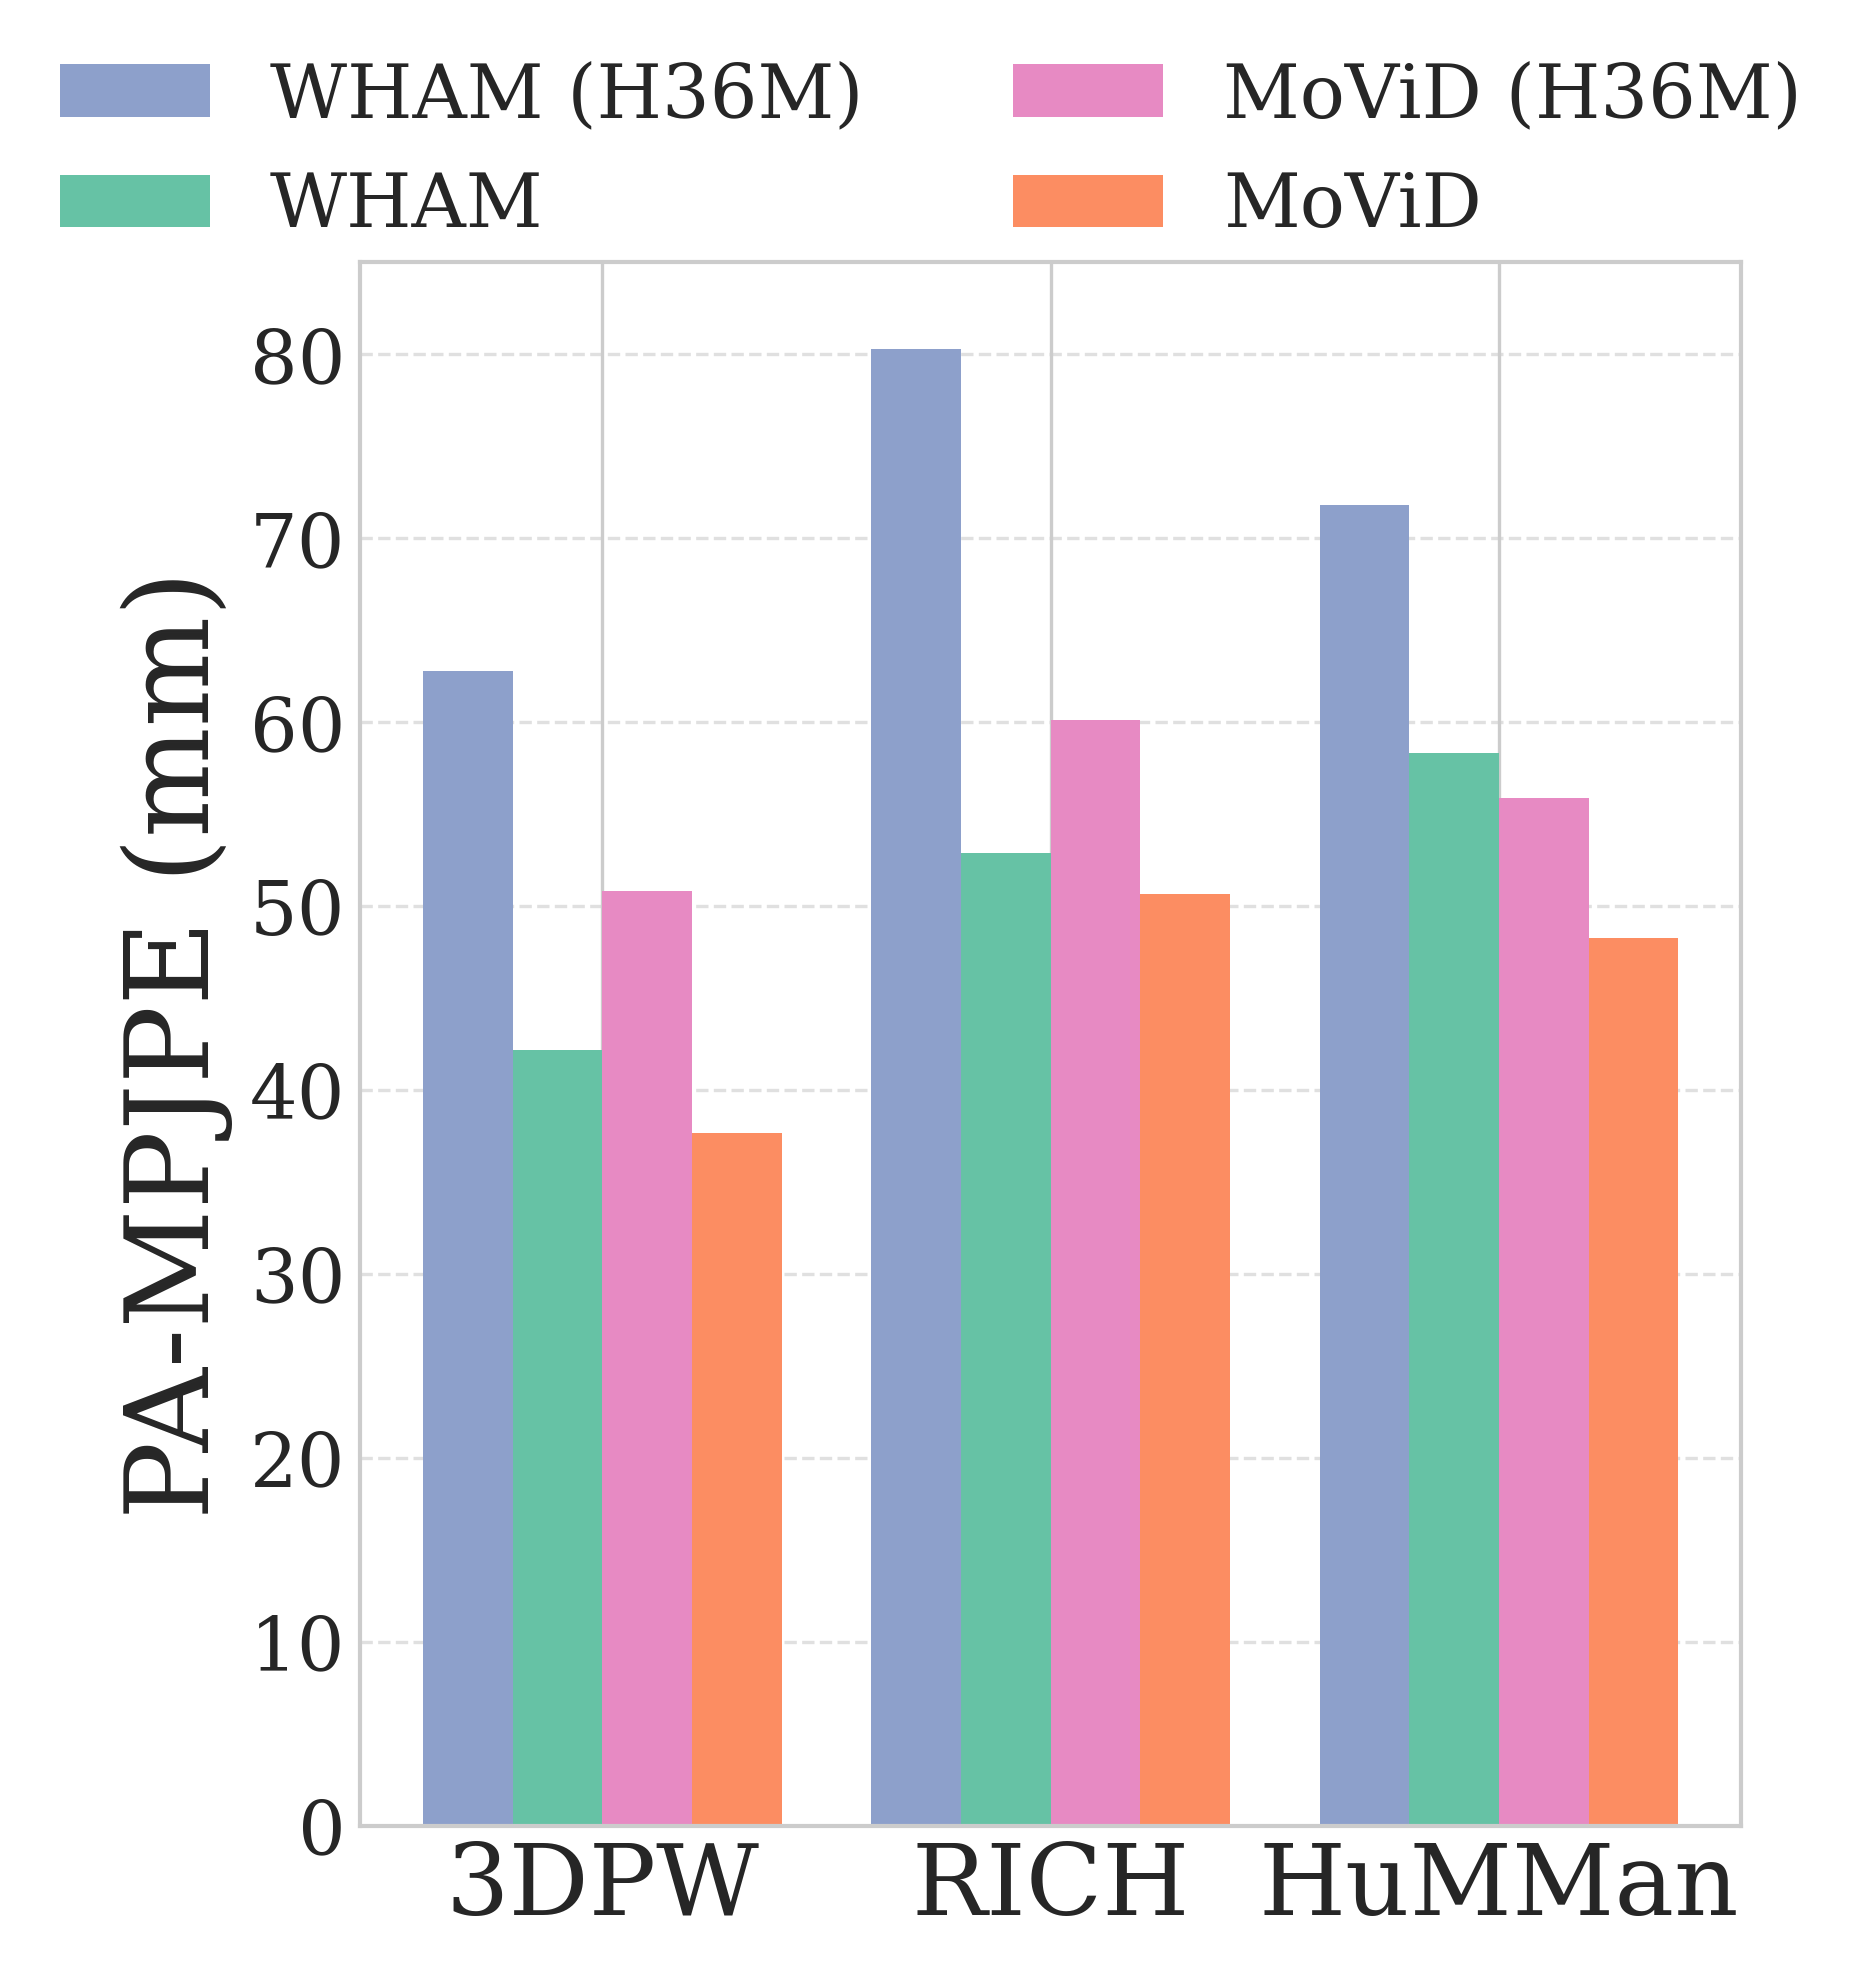

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# === 数据准备 ===
datasets = ['3DPW', 'RICH', 'HuMMan']
metric = 'PA-MPJPE'
wham_h36m = [62.79, 80.27, 71.80]
ours_h36m = [50.83, 60.08, 55.88]
wham = [42.18, 52.85, 58.32]
ours = [37.65, 50.63, 48.26]

# === 颜色 ===
COLORS = {
    'wham_h36m': '#8da0cb',
    'wham': '#66c2a5',
    'ours_h36m': '#e78ac3',
    'ours': '#fc8d62'
}

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 20,
    'axes.titlesize': 22,
    'axes.labelsize': 20,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 20,
    'figure.dpi': 300,
})

# === Figure: 严格 9:6 比例 ===
fig = plt.figure(figsize=(9, 6))
# 下移绘图区，为 legend 预留顶部空间
ax = fig.add_axes([0.12, 0.12, 0.83, 0.70])  # left, bottom, width, height

x = np.arange(len(datasets))
width = 0.2

# === 绘制条形图 ===
ax.bar(x - 1.5*width, wham_h36m, width, label='WHAM (H36M)', color=COLORS['wham_h36m'])
ax.bar(x - 0.5*width, wham, width, label='WHAM', color=COLORS['wham'])
ax.bar(x + 0.5*width, ours_h36m, width, label='MoViD (H36M)', color=COLORS['ours_h36m'])
ax.bar(x + 1.5*width, ours, width, label='MoViD', color=COLORS['ours'])

# === 坐标轴 ===
ax.set_ylabel('PA-MPJPE (mm)', fontsize=28)
ax.set_xticks(x)
ax.set_xticklabels(datasets, fontsize=24)
ax.set_ylim(0, 85)
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.set_axisbelow(True)

# === Legend: 图内上带，不遮挡 ===
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.01),  # 图内上方留白区域
    ncol=2,
    frameon=False,
    prop={'size': 24}
)

# === 严格输出，不使用 tight ===
fig.set_size_inches(9, 6)  # 锁定物理尺寸
fig.savefig('new_figures/pose_pa_mpjpe_comparison.png', dpi=300)
plt.show()


/var/folders/0d/kphf81916s32j4912vbz_4t80000gn/T/ipykernel_93871/356336929.py:80: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


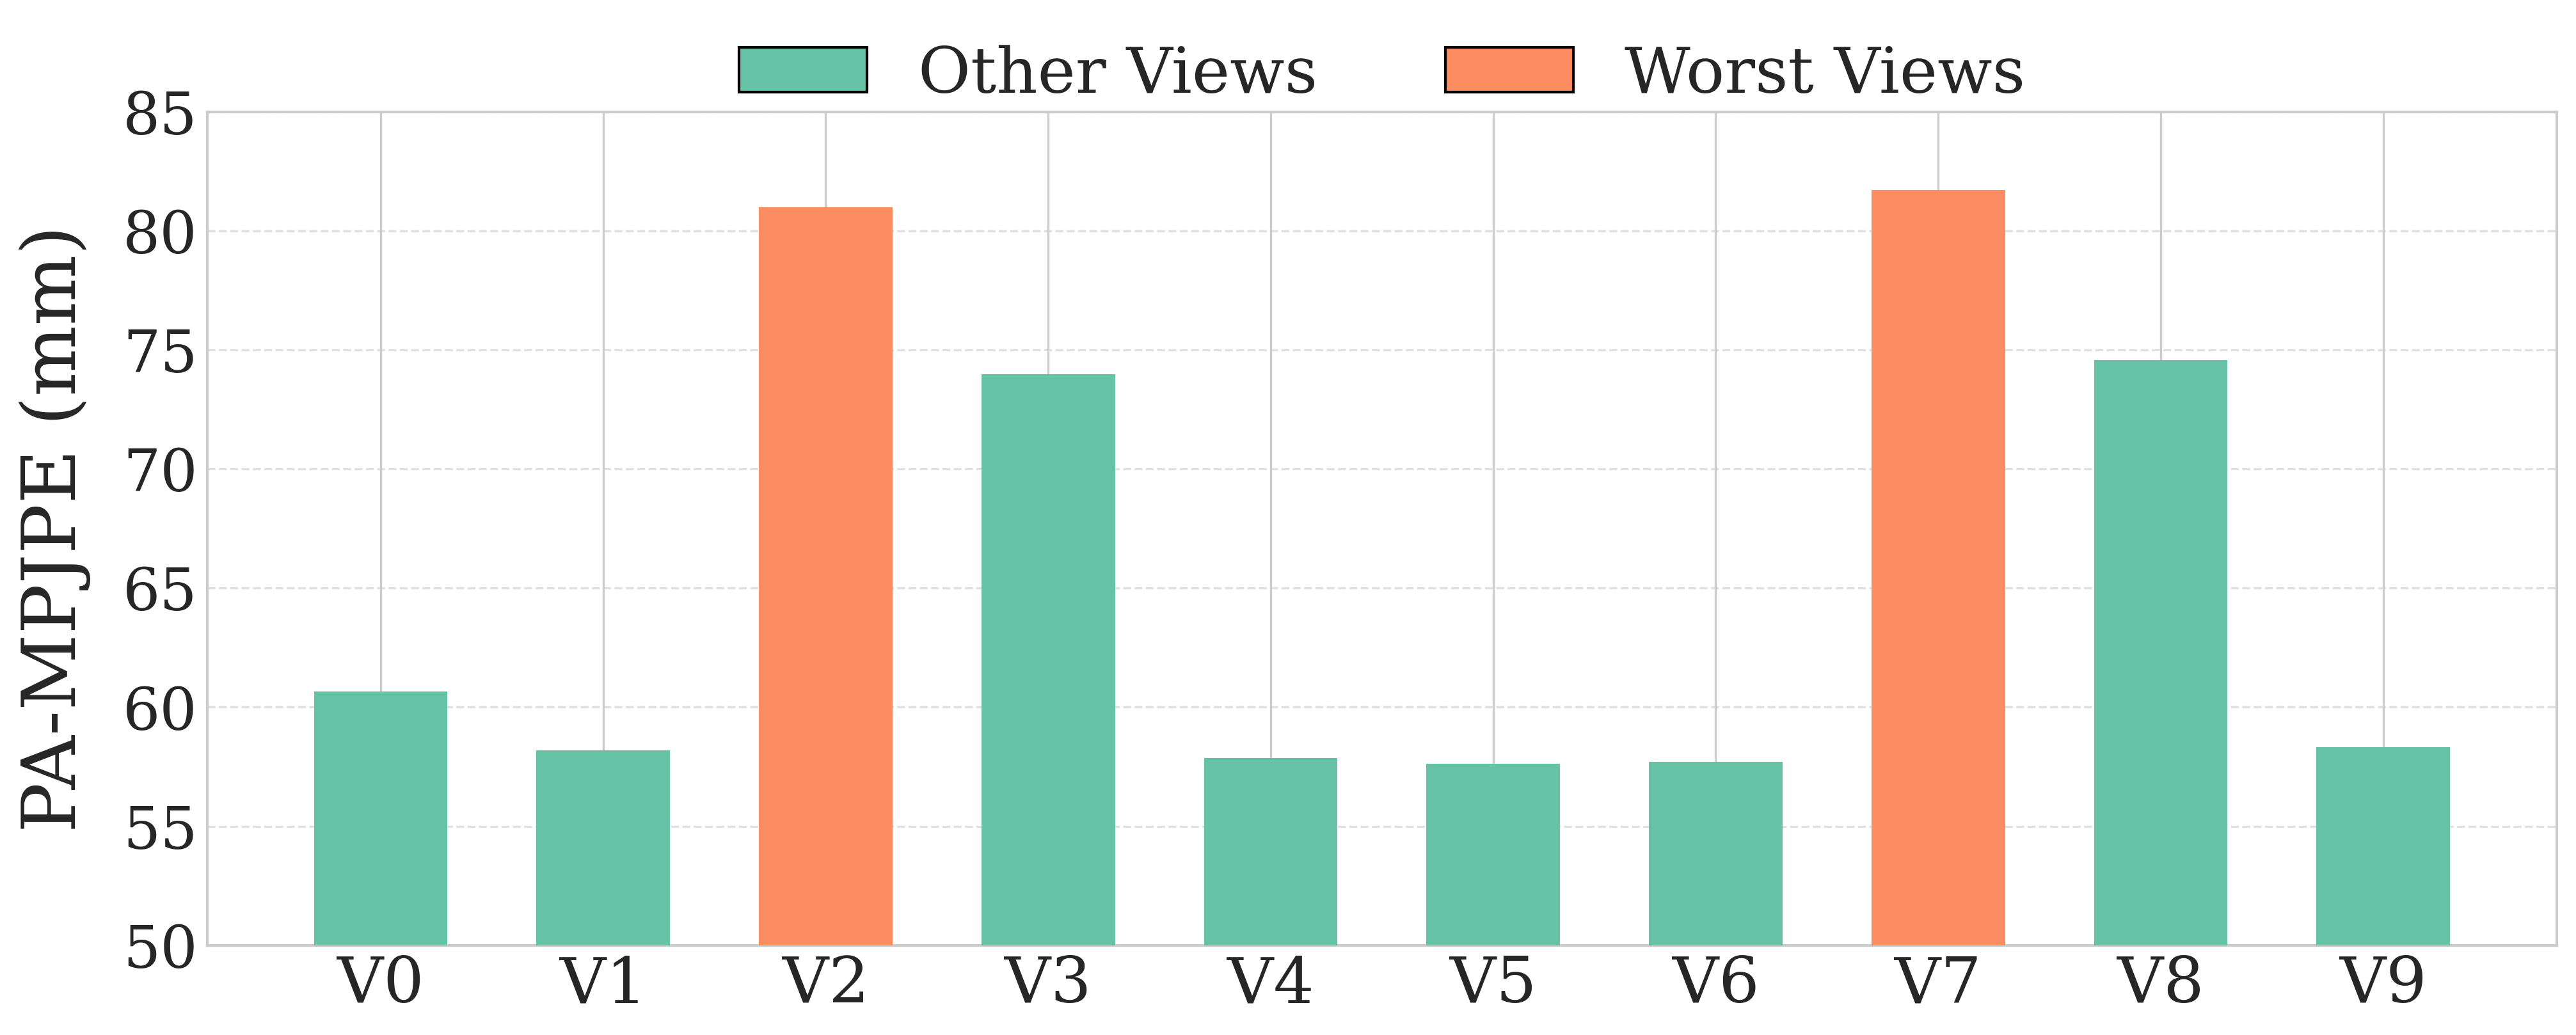

In [41]:
import matplotlib

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# === 全局样式 ===
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 26,
    'axes.titlesize': 28,
    'axes.labelsize': 26,
    'xtick.labelsize': 22,
    'ytick.labelsize': 22,
    'legend.fontsize': 22,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.format': 'png',
    'savefig.bbox': 'tight'
})

# === 数据 ===
views = [f'V{i}' for i in range(10)]
metrics = {
    'PA-MPJPE': [60.6479, 58.1781, 80.9933, 73.9750, 57.8699, 57.6282, 57.6957, 81.7306, 74.5832, 58.3167],
}

# === 配色方案 ===
base_color = '#66c2a5'
highlight_color = '#fc8d62'
y_limits = {'PA-MPJPE': (50, 85)}

# === 10 个 pattern（每个 bar 一个） ===
patterns = ['/', '\\', '|', '-', '+', 'x', 'o', 'O', '.', '*']

# === 绘图 ===
fig, ax = plt.subplots(figsize=(16, 6))

for metric_name, values in metrics.items():
    # 找出最差两项索引
    sorted_indices = np.argsort(values)
    bottom2_indices = sorted_indices[-2:]

    # 设置颜色：默认绿色，最差两项橙色
    colors = [base_color if i not in bottom2_indices else highlight_color for i in range(len(values))]

    # 绘制柱状图：为每个 bar 加不同 hatch
    bars = ax.bar(
        views, values,
        color=colors,
        edgecolor='black',
        linewidth=1,
        width=0.6,
        zorder=3
    )

    # 给每个 bar 加 pattern
    for i, bar in enumerate(bars):
        bar.set_hatch(patterns[i % len(patterns)])

    # 坐标轴等
    ax.set_ylabel(f'{metric_name} (mm)', fontsize=28, labelpad=12)
    ax.set_xticks(range(len(views)))
    ax.set_xticklabels(views, fontsize=24)
    ax.set_ylim(y_limits[metric_name])
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.set_axisbelow(True)

# === 图例（不使用 hatch，保持纯色） ===
legend_elements = [
    Patch(facecolor=base_color, edgecolor='black', label='Other Views'),
    Patch(facecolor=highlight_color, edgecolor='black', label='Worst Views'),
]

plt.tight_layout(rect=[0, 0, 1, 0.9])
ax.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),
    ncol=2,
    frameon=False,
    prop={'size': 24}
)

plt.subplots_adjust(top=0.85)
plt.savefig('new_figures/View_Info_4.png', bbox_inches='tight', dpi=300)
plt.show()


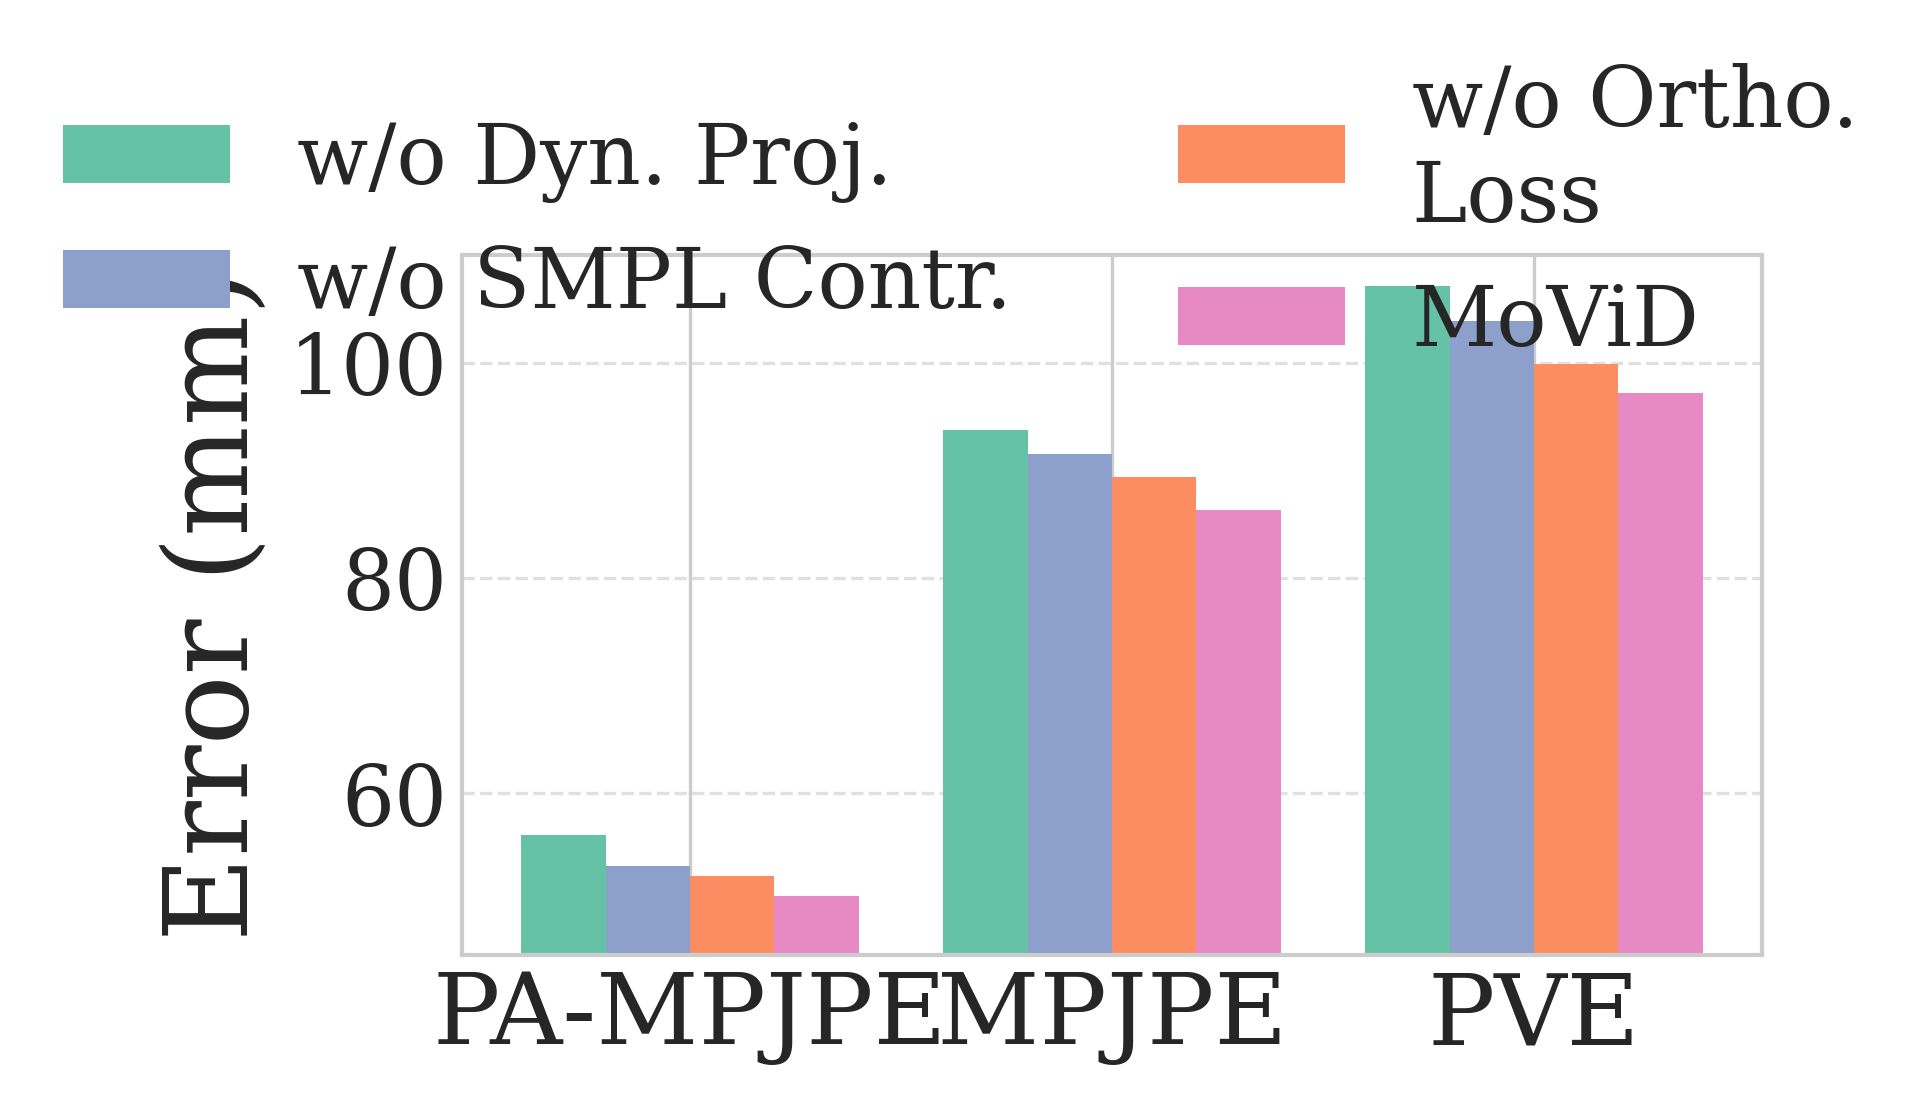

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# === 数据 ===
methods = ["w/o Dyn. Proj.", "w/o SMPL Contr.", "w/o Ortho. Loss", "MoViD"]
metrics = ["PA-MPJPE", "MPJPE", "PVE"]
data = np.array([
    [56.1, 93.7, 107.14],
    [53.2, 91.5, 103.9],
    [52.3, 89.4, 99.88],
    [50.4, 86.3, 97.2]
])

# === 全局风格 ===
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 22,
    'axes.titlesize': 24,
    'axes.labelsize': 22,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 20,
    'figure.dpi': 300,
})

colors = ['#66c2a5', '#8da0cb', '#fc8d62', '#e78ac3']
x = np.arange(len(metrics))
width = 0.2

# === Figure: 严格 6:4 比例 ===
fig = plt.figure(figsize=(9, 6))  # 画布严格 6:4
# 上面专门留 0.20 高度给 legend，绘图区高度 0.68 不会被遮挡
ax = fig.add_axes([0.12, 0.12, 0.83, 0.68])  # [left, bottom, width, height]

# === 绘制柱状图 ===
for i, method in enumerate(methods):
    ax.bar(
        x + i * width, data[i], width,
        label=method, color=colors[i], edgecolor='none'
    )

# === 坐标轴样式 ===
ax.set_ylabel('Error (mm)', fontsize=28)
ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(metrics, fontsize=24)
ax.set_ylim(45, 110)
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.set_axisbelow(True)

# === Legend：图内上边带，不遮挡 ===
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.02),   # 在图内上边带居中
    ncol=2,
    frameon=False,
    fontsize=24
)

# === 严格输出比例（不要用 tight！）===
# fig.set_size_inches(9, 6)  # 再次锁定物理尺寸
fig.savefig('new_figures/ablation_study_comparison.png', dpi=300)  # 不用 bbox_inches
plt.show()


In [8]:
import matplotlib.pyplot as plt
import numpy as np

# === 数据 ===
camera_motion_categories = ['Lateral\nFollow', 'Surround', 'Ascending\nDescending', 'Mixed']
human_motion_categories = ['Walking', 'Jogging', 'Single-leg\nHop', 'Lunge', 'Mixed']

ours_pa_mpjpe_camera = [23, 25, 27, 26]
wham_pa_mpjpe_camera = [26, 29, 32, 29]
ours_pa_mpjpe_motion = [24, 25, 29, 27, 26]
wham_pa_mpjpe_motion = [27, 29, 32, 31, 29]

# === 风格设置 ===
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 24,
    'axes.labelsize': 28,
    'xtick.labelsize': 24,
    'ytick.labelsize': 24,
    'legend.fontsize': 24,
    'figure.dpi': 300,
})

colors = ['#66c2a5', '#fc8d62']
width = 0.35


# === 单图绘制函数 ===
def plot_single(categories, ours, wham, save_path):
    fig, ax = plt.subplots(figsize=(12, 5))

    x = np.arange(len(categories))

    bars1 = ax.bar(x - width/2, ours, width,
                   label="Ours", color=colors[0], edgecolor='none')
    bars2 = ax.bar(x + width/2, wham, width,
                   label="WHAM", color=colors[1], edgecolor='none')

    ax.set_xticks(x)
    ax.set_xticklabels(categories, fontsize=24)
    ax.set_ylim(0, 35)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.set_axisbelow(True)
    ax.set_ylabel("PA-MPJPE (mm) ↓", fontsize=28)

    # === Legend 放顶部（不遮挡图） ===
    handles, labels = ax.get_legend_handles_labels()
    leg = fig.legend(handles, labels,
                     loc='upper center',
                     bbox_to_anchor=(0.5, 1.04),
                     ncol=2,
                     frameon=False,
                     prop={'size': 24})

    plt.tight_layout(rect=[0, 0, 1, 0.98])  # 给 legend 留位置
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.close(fig)


# === 单独保存两张图 ===
plot_single(
    categories=camera_motion_categories,
    ours=ours_pa_mpjpe_camera,
    wham=wham_pa_mpjpe_camera,
    save_path="./new_figures/pa_mpjpe_camera_motion.png"
)

plot_single(
    categories=human_motion_categories,
    ours=ours_pa_mpjpe_motion,
    wham=wham_pa_mpjpe_motion,
    save_path="./new_figures/pa_mpjpe_human_motion.png"
)

print("Saved:")
print(" - ./new_figures/pa_mpjpe_camera_motion.png")
print(" - ./new_figures/pa_mpjpe_human_motion.png")


Saved:
 - ./new_figures/pa_mpjpe_camera_motion.png
 - ./new_figures/pa_mpjpe_human_motion.png


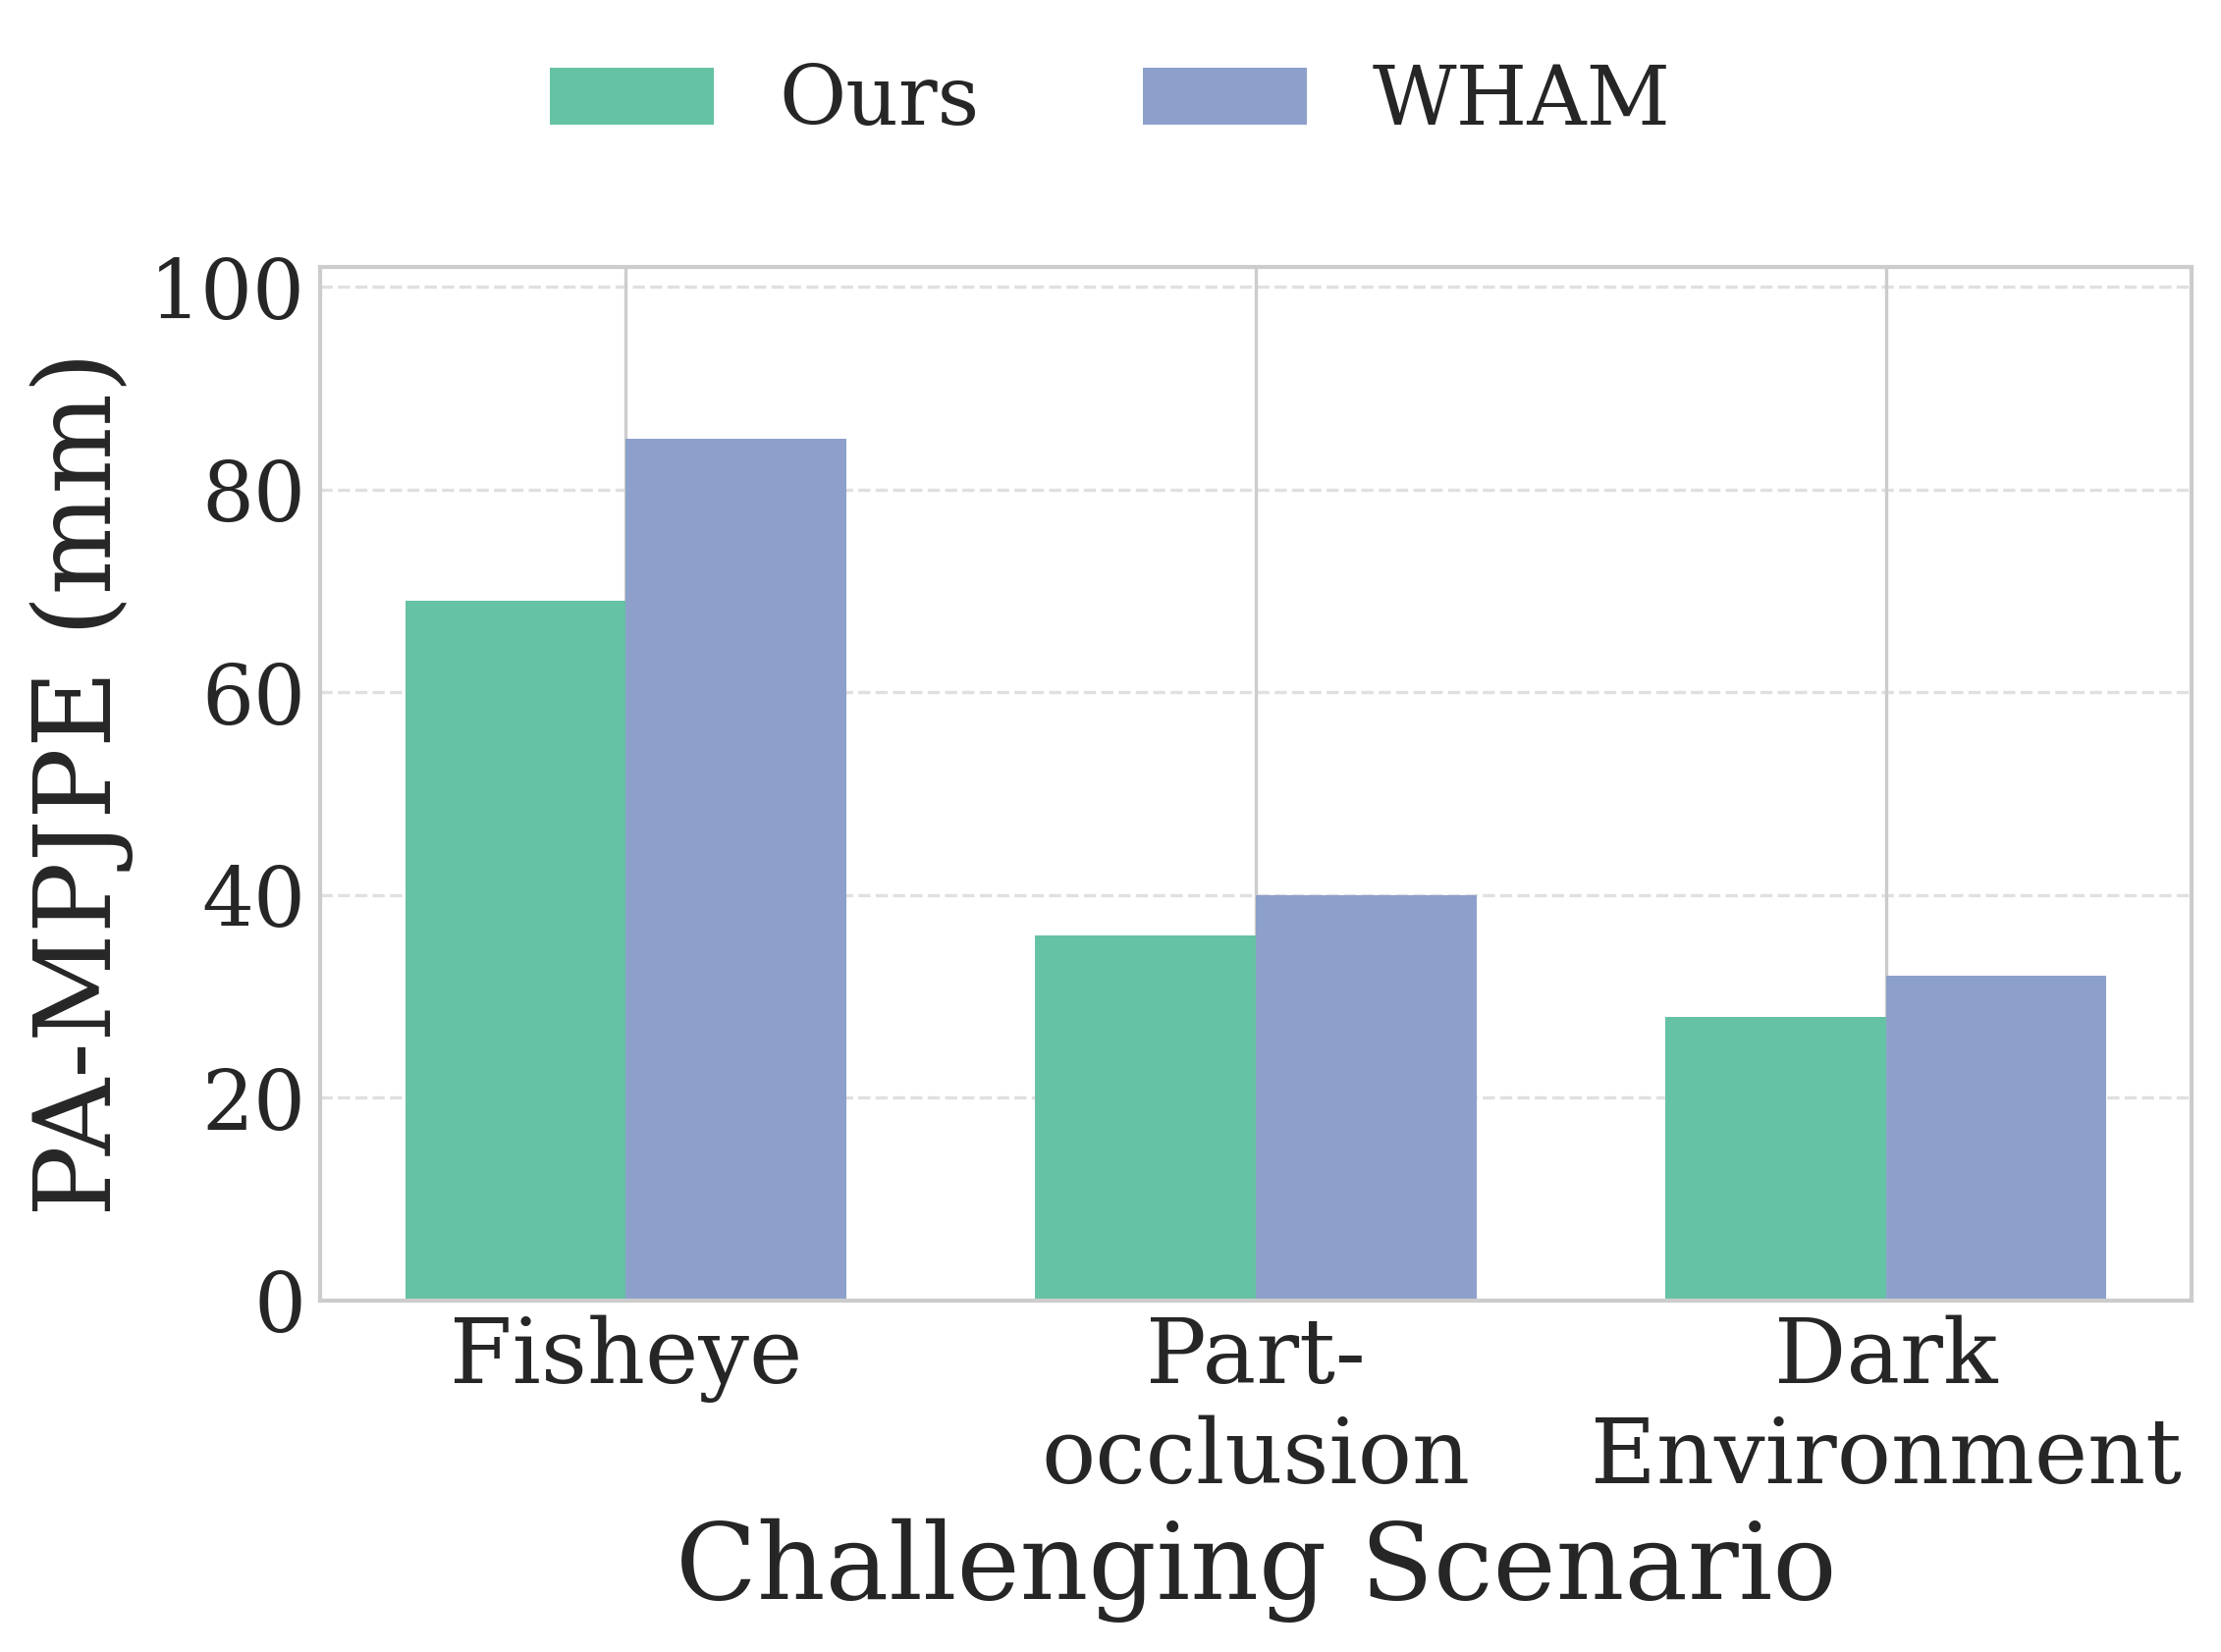

PNG figure saved to: ./pa_mpjpe_challenging_scenarios_unified.png


In [33]:
import matplotlib.pyplot as plt
import numpy as np

# === 数据 ===
scenarios = ['Fisheye', 'Part-\nocclusion', 'Dark\nEnvironment']
ours_pa_mpjpe = [69, 36, 28]
wham_pa_mpjpe = [85, 40, 32]

# === 风格设置 ===
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 22,
    'axes.titlesize': 24,
    'axes.labelsize': 22,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 20,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.format': 'png',
    'savefig.bbox': 'tight'
})

# === 颜色方案（与前面统一） ===
colors = ['#66c2a5', '#8da0cb']  # ours / wham
bar_width = 0.35
x = np.arange(len(scenarios))

# === 绘图 ===
fig, ax = plt.subplots(figsize=(8, 6))

bars1 = ax.bar(x - bar_width/2, ours_pa_mpjpe, bar_width, label='Ours',
               color=colors[0], edgecolor='none', linewidth=0)
bars2 = ax.bar(x + bar_width/2, wham_pa_mpjpe, bar_width, label='WHAM',
               color=colors[1], edgecolor='none', linewidth=0)

# === 坐标轴样式 ===
ax.set_ylabel('PA-MPJPE (mm)', fontsize=26)
ax.set_xlabel('Challenging Scenario', fontsize=26)
ax.set_xticks(x)
ax.set_xticklabels(scenarios, fontsize=22)
ax.set_ylim(0, max(wham_pa_mpjpe) * 1.2)
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.set_axisbelow(True)

# === 添加数值标签 ===
# for bars in [bars1, bars2]:
#     for bar in bars:
#         h = bar.get_height()
#         ax.text(bar.get_x() + bar.get_width()/2, h + 1.5,
#                 f'{int(h)}', ha='center', va='bottom',
#                 fontsize=18, fontweight='bold')

# === Legend（放顶部，居中，2列） ===
handles, labels = ax.get_legend_handles_labels()
leg = fig.legend(handles, labels,
                 loc='upper center',
                 bbox_to_anchor=(0.5, 0.98),
                 ncol=2,
                 frameon=False,
                 prop={'size': 20})

# === 布局调整 ===
plt.tight_layout(rect=[0, 0, 1, 0.88])

# === 保存与展示 ===
plt.savefig('./pa_mpjpe_challenging_scenarios_unified.png',
            bbox_inches='tight', bbox_extra_artists=(leg,), dpi=300)
plt.show()

print("PNG figure saved to: ./pa_mpjpe_challenging_scenarios_unified.png")


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

# === 创建保存目录 ===
os.makedirs('./new_figures', exist_ok=True)

# === 原始数据 ===
PA_MPJPE = np.array([36.8300, 32.5335, 46.7236, 40.6789, 32.8412,
                     37.5483, 32.7814, 44.3175, 40.3040, 32.9663])
PA_MPJPE_STD = np.array([12.5561, 9.9494, 16.4511, 15.2512, 10.3372,
                         13.2684, 10.5351, 15.5350, 13.8632, 10.5297])

COS_SIM = np.array([0.9561, 0.9784, 0.9632, 0.9821, 0.9827,
                    0.9582, 0.9322, 0.8763, 0.9113, 0.9432])
COS_SIM_STD = np.array([0.0187, 0.0113, 0.0133, 0.0081, 0.0090,
                        0.0164, 0.0218, 0.0245, 0.0215, 0.0216])

# === 平均指定视角 ===
views_merged = ['Front', 'Front\nOblique', 'Downward\nSide', 'Side', 'Back\nOblique', 'Back']

PA_MPJPE_merged = np.array([
    PA_MPJPE[0],
    (PA_MPJPE[1] + PA_MPJPE[9]) / 2,
    (PA_MPJPE[2] + PA_MPJPE[7]) / 2,
    (PA_MPJPE[3] + PA_MPJPE[8]) / 2,
    (PA_MPJPE[4] + PA_MPJPE[6]) / 2,
    PA_MPJPE[5]
])

PA_MPJPE_STD_merged = np.array([
    PA_MPJPE_STD[0],
    np.sqrt(PA_MPJPE_STD[1]**2 + PA_MPJPE_STD[9]**2) / 2,
    np.sqrt(PA_MPJPE_STD[2]**2 + PA_MPJPE_STD[7]**2) / 2,
    np.sqrt(PA_MPJPE_STD[3]**2 + PA_MPJPE_STD[8]**2) / 2,
    np.sqrt(PA_MPJPE_STD[4]**2 + PA_MPJPE_STD[6]**2) / 2,
    PA_MPJPE_STD[5]
])

COS_SIM_merged = np.array([
    COS_SIM[0],
    (COS_SIM[1] + COS_SIM[9]) / 2,
    (COS_SIM[2] + COS_SIM[7]) / 2,
    (COS_SIM[3] + COS_SIM[8]) / 2,
    (COS_SIM[4] + COS_SIM[6]) / 2,
    COS_SIM[5]
])

COS_SIM_STD_merged = np.array([
    COS_SIM_STD[0],
    np.sqrt(COS_SIM_STD[1]**2 + COS_SIM_STD[9]**2) / 2,
    np.sqrt(COS_SIM_STD[2]**2 + COS_SIM_STD[7]**2) / 2,
    np.sqrt(COS_SIM_STD[3]**2 + COS_SIM_STD[8]**2) / 2,
    np.sqrt(COS_SIM_STD[4]**2 + COS_SIM_STD[6]**2) / 2,
    COS_SIM_STD[5]
])

# === 按 PA-MPJPE 升序排序 ===
sort_idx = np.argsort(PA_MPJPE_merged)

views_sorted = [views_merged[i] for i in sort_idx]
PA_sorted = PA_MPJPE_merged[sort_idx]
PA_std_sorted = PA_MPJPE_STD_merged[sort_idx]
COS_sorted = COS_SIM_merged[sort_idx]
COS_std_sorted = COS_SIM_STD_merged[sort_idx]

x = np.arange(len(views_sorted))

# === 配色与样式 ===
color_pose = '#fc8d62'
color_view = '#000000'

# === Figure 1: View Estimation Accuracy Across Views ===
fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(
    x, COS_sorted, yerr=COS_std_sorted * 0.6,
    fmt='-o', color=color_view, ecolor='gray',
    markersize=7, linewidth=2.0, capsize=2, alpha=0.9
)
ax.set_ylabel('View Estimation Accuracy', fontsize=28)
ax.set_xlabel('View', fontsize=28)
ax.set_ylim(0.7, 1.0)
ax.set_xticks(x)
ax.set_xticklabels(views_sorted, fontsize=22, ha='center')
ax.tick_params(axis='y', labelsize=22)
ax.grid(axis='y', linestyle='--', linewidth=1.0, alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('./new_figures/view_estimation_accuracy_across_views.png', dpi=300, bbox_inches='tight')
plt.show()

# === Figure 2: Pose Estimation Error Across Views ===
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(
    x, PA_sorted, width=0.55, yerr=PA_std_sorted * 0.6,
    color=color_pose, edgecolor='black', linewidth=1,
    alpha=0.95, capsize=3,
    error_kw=dict(elinewidth=1.0, ecolor='black', alpha=0.5)
)
ax.set_ylabel('PA-MPJPE (mm) ↓', fontsize=28)
ax.set_xlabel('View', fontsize=28)
ax.set_ylim(0, np.max(PA_sorted) + 20)
ax.set_xticks(x)
ax.set_xticklabels(views_sorted, fontsize=22, ha='center')
ax.tick_params(axis='y', labelsize=22)
ax.grid(axis='y', linestyle='--', linewidth=1.0, alpha=0.6)
ax.axhline(y=0, color='black', linewidth=1.2)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('./new_figures/pose_estimation_error_across_views.png', dpi=300, bbox_inches='tight')
plt.show()


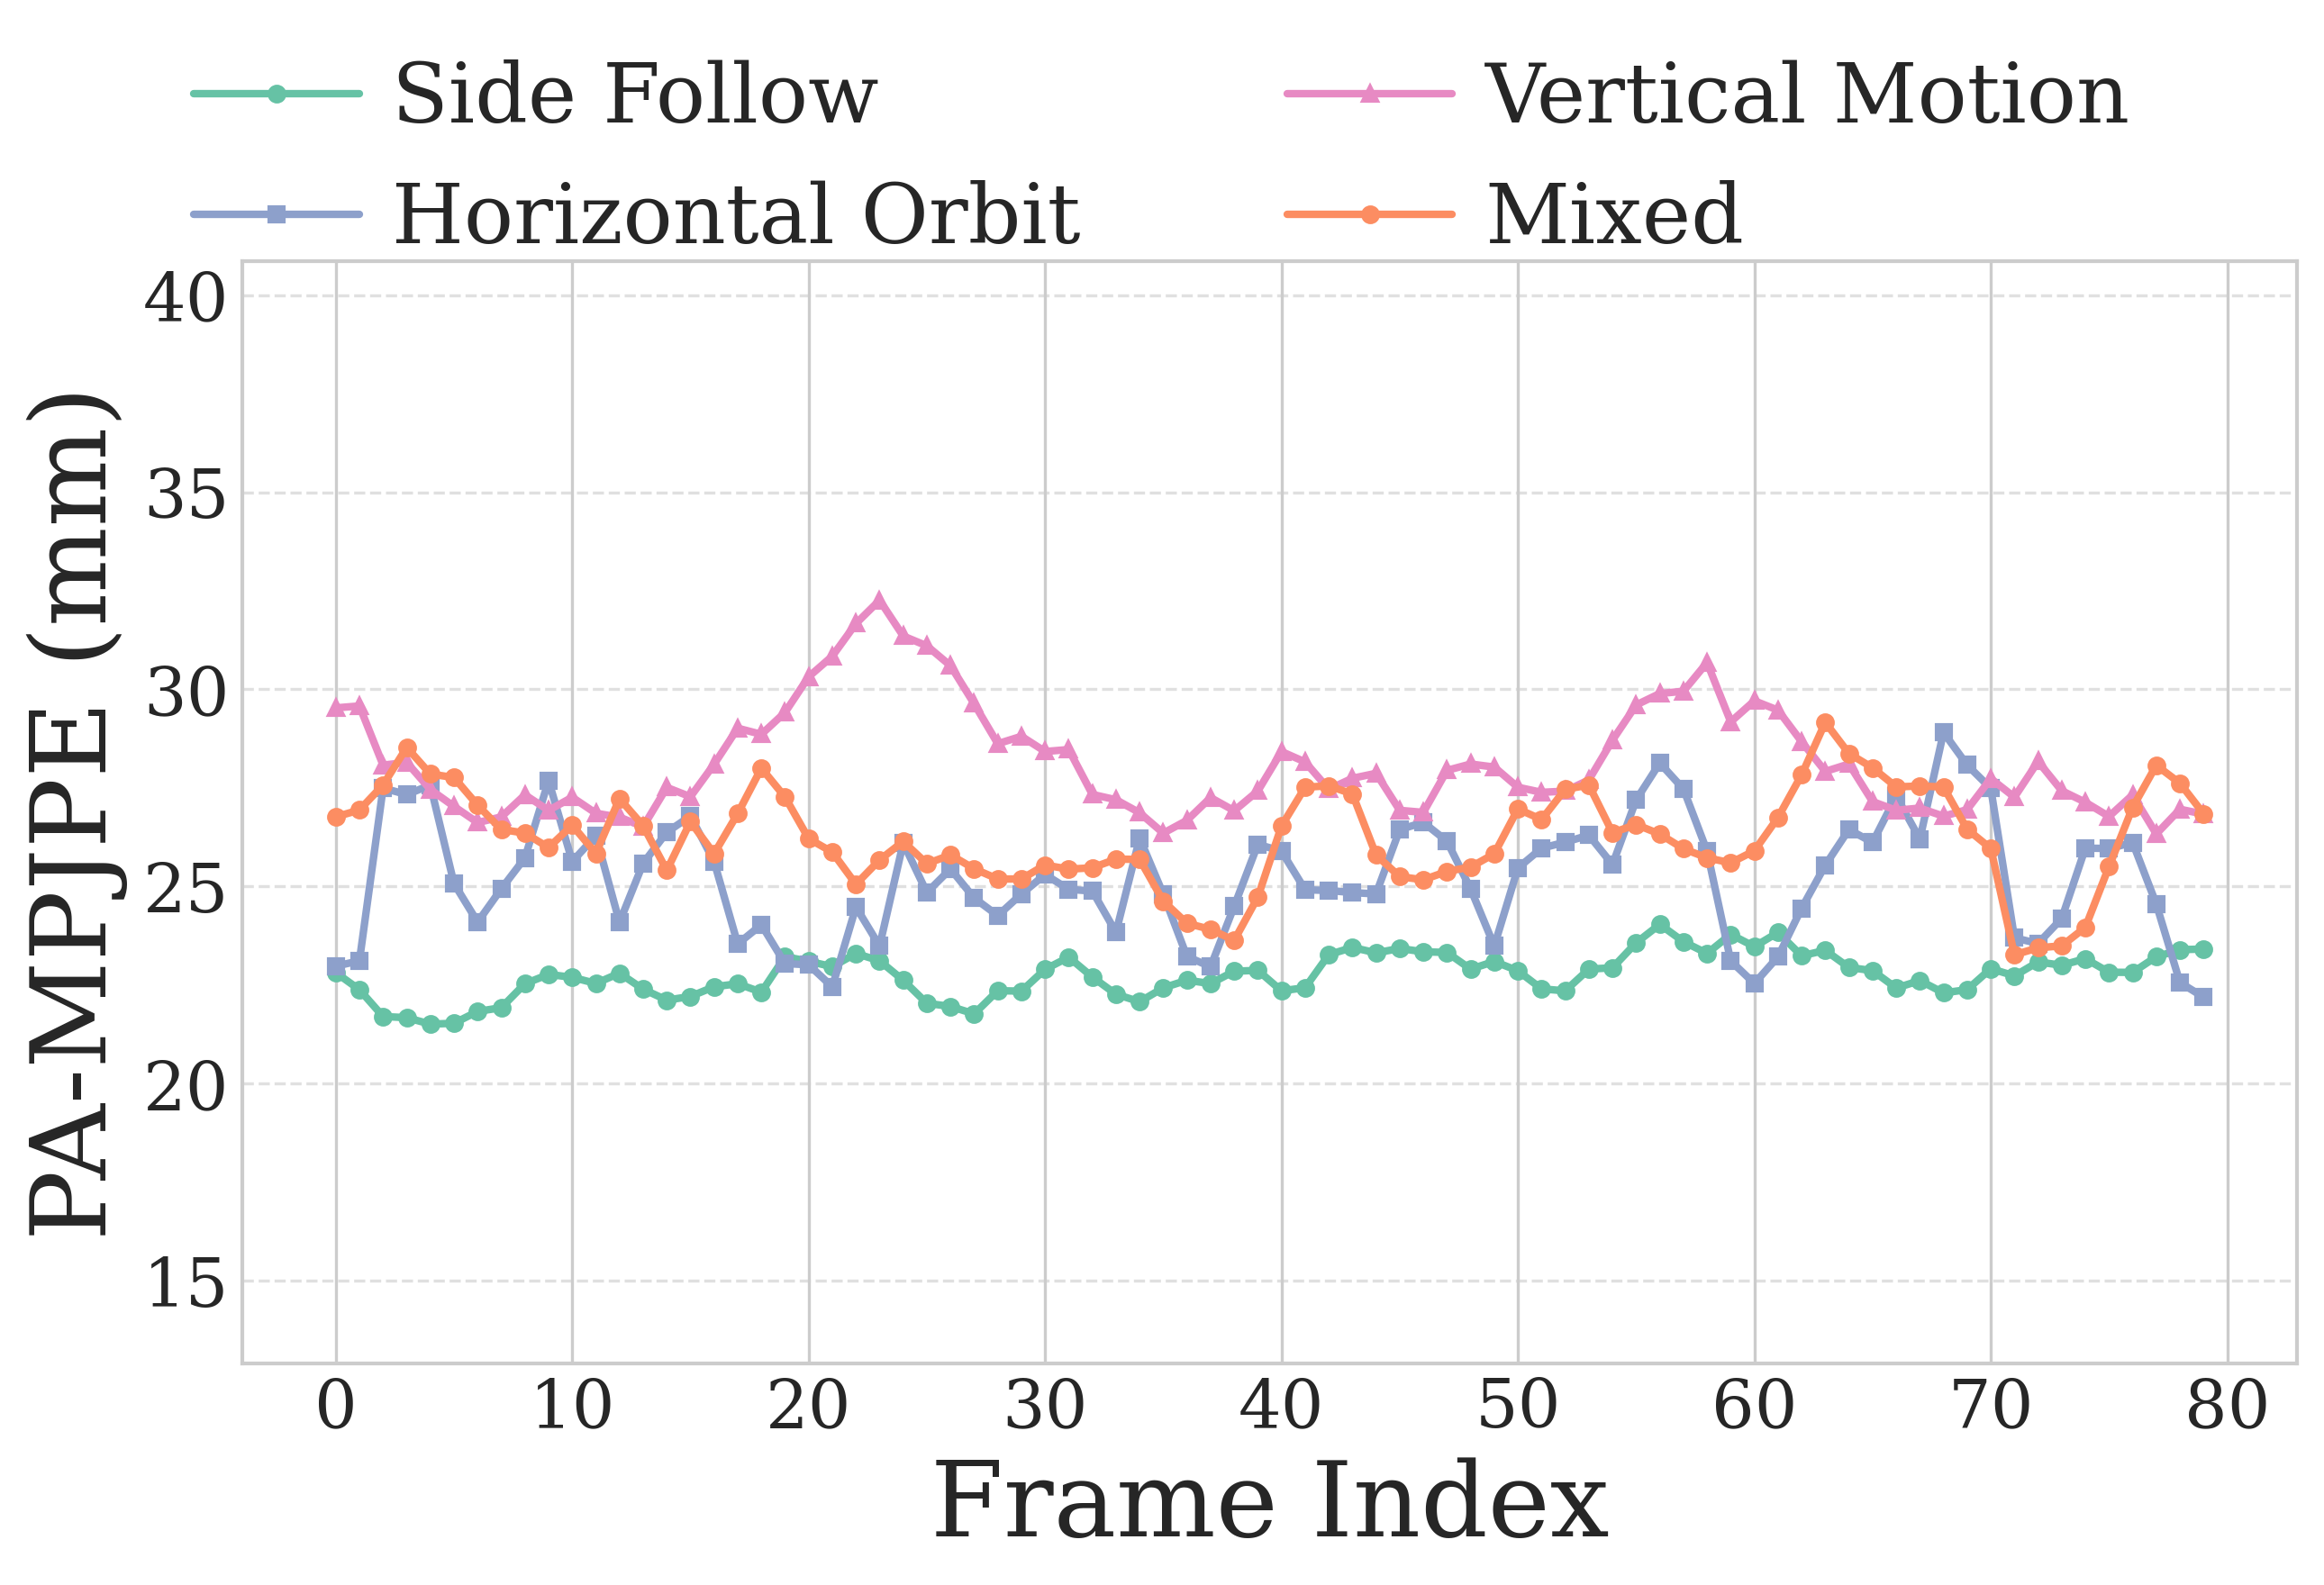

Saved to ./new_figures/error_trajectory_camera_motion.png


In [35]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# === 样式 ===
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 20,
    'axes.titlesize': 22,
    'axes.labelsize': 20,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 22,
    'figure.dpi': 300,
})

# === 颜色 ===
base_colors = ['#66c2a5', '#8da0cb', '#e78ac3']
custom_last_color = '#fc8d62'   # ← 你说“最后一种颜色用这个”

markers = ['o', 's', '^', 'x']
linestyles = ['-', '-', '-', '-']


def visualize_error_trajectory(error_data_dict, save_path):

    fig, ax = plt.subplots(figsize=(9, 6))

    # === 绘制曲线 ===
    for idx, (name, arr) in enumerate(error_data_dict.items()):
        frames = np.arange(len(arr))

        if idx < 3:
            color = base_colors[idx]
        else:
            color = custom_last_color

        ax.plot(
            frames, arr,
            color=color,
            linestyle=linestyles[idx % 3],
            marker=markers[idx % 3],
            linewidth=2,
            markersize=4,
            label=name
        )

    # === Y 范围 ===
    all_vals = np.concatenate(list(error_data_dict.values()))
    margin = (np.max(all_vals) - np.min(all_vals)) * 0.8
    ax.set_ylim(np.min(all_vals) - margin, np.max(all_vals) + margin)

    ax.set_xlabel("Frame Index", fontsize=28)
    ax.set_ylabel("PA-MPJPE (mm)", fontsize=28)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.set_axisbelow(True)

    # ⭐⭐ 关键：legend 放在 figure 内部顶部，不撑大 figsize
    fig.legend(
        loc='upper center',
        ncol=2,
        frameon=False,
        bbox_to_anchor=(0.5, 1.02),  # ← 贴近最上方，但仍在内部
        columnspacing=2.5,
        handletextpad=0.4
    )

    # ⭐⭐ 关键：tight_layout 保留 legend 区域
    plt.tight_layout(rect=[0, 0, 1, 0.9])

    # 输出严格 9×6 英寸（dpi=300 → 2700×1800px）
    plt.savefig(save_path, dpi=300)
    plt.show()

    print(f"Saved to {save_path}")


# ==========================================================
# 演示数据（不变）
# ==========================================================
np.random.seed(42)
num_frames = 100
trim = 10

side = 23 + np.random.randn(num_frames) * 1.5
side = np.convolve(side, np.ones(5)/5, mode='same')[trim:-trim]

horizontal = 25 + np.random.randn(num_frames) * 3.0
horizontal = np.convolve(horizontal, np.ones(3)/3, mode='same')[trim:-trim]

vertical = 27 + np.random.randn(num_frames) * 1.8
peak1, peak2, w = num_frames//3, 2*num_frames//3, 10
for i in range(num_frames):
    if abs(i - peak1) < w:
        vertical[i] += 5*(1 - abs(i-peak1)/w)
    if abs(i - peak2) < w:
        vertical[i] += 4*(1 - abs(i-peak2)/w)
vertical = np.convolve(vertical, np.ones(5)/5, mode='same')[trim:-trim]

mixed = 26 + np.random.randn(num_frames) * 2.5
mixed = np.convolve(mixed, np.ones(4)/4, mode='same')[trim:-trim]

error_data = {
    'Side Follow': side,
    'Horizontal Orbit': horizontal,
    'Vertical Motion': vertical,
    'Mixed': mixed,
}

visualize_error_trajectory(error_data, './new_figures/error_trajectory_camera_motion.png')
